In [1]:
!pip install -q dm-haiku optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 3.7 MB/s eta 0:00:00


In [2]:
# %%
# Cell 1: Environment Setup & Imports (V17.8 — RECONCILIATION RELEASE)
#
# 💥 WHY V17.8 EXISTS:
# Two independently-produced "V17.7" deliverables (code + proposal) existed in this project's
# Knowledge Base, each claiming to respond to a review pass on V17.6, but covering DISJOINT and
# in one case MUTUALLY EXCLUSIVE ground:
#
#   "Series 1" (peer-review response release, CHANGELOG_V17_7_CODE.md / Proposal_V17_7_EN.md):
#     - Found and fixed a CRITICAL, previously undetected numerical instability in Cell 3's
#       ground-truth generator: centered-difference advection under forward-Euler time
#       stepping engaged the clip/nan_to_num safety valve on ~84% of timesteps in a smoke-test
#       run, confirmed present in the unmodified V17.6 code. Fixed via first-order upwind
#       differencing for the advection terms only.
#     - Rewrote Cell 8's evaluation to a full post-spin-up-trajectory protocol (not t=0).
#     - Implemented the Adam-vs-L-BFGS RMSE(Cf) comparison that VB13 had only ever been a
#       prose commitment for (config.EVALUATE_ADAM_STAGE_SEPARATELY).
#     - Raised LBFGS_MAX_PHYSICS_POINTS 5000 -> 20000 as a partial VB13/VB15 mitigation.
#     - Sharper (still stable) synthetic Cf field, rotating synthetic wind.
#     Did NOT touch: Cell 5's redundant JVP calls in the diffusion term, and had no L-BFGS
#     point-subset sensitivity-sweep tooling.
#
#   "Series 2" (independent methodological + citation review, CHANGELOG_V17_7.md):
#     - Fixed a real inefficiency in Cell 5: the diffusion second-derivative block ran 4
#       independent outer jax.jvp calls where 2 suffice (predict_uv_x/predict_uv_y each return
#       BOTH velocity components), halving the JVP count for that term with no physics change.
#     - Added PINNDataset.get_full_batch_for_lbfgs(seed=...) and
#       train_lbfgs_scipy(subset_seed=..., weight_suffix=...) plus
#       run_lbfgs_subset_sensitivity_sweep() — a genuine, additional VB13 addendum tool that
#       Series 1 lacks: it directly measures L-BFGS-B's sensitivity to WHICH fixed physics
#       subsample is drawn, rather than only enlarging the subsample once.
#     - Added an explicit assert in Cell 8 guarding against a SMOKE_TEST run silently
#       corrupting the canonical ablation table.
#     - Attempted a citation correction to Tian et al. (2025)'s author order to "Huang, Su" —
#       INDEPENDENTLY RE-VERIFIED during this reconciliation (arXiv:2501.11372; PLOS ONE and
#       Keppler et al. 2026 WRR citations of the same paper) and found to be WRONG. The
#       correct, published order is Tian, Ding, SU, HUANG, Chen — i.e. Series 1's original
#       (unmodified) ordering was already correct. Series 2 introduced a citation error while
#       believing it was fixing one. This reconciliation reverts to the verified order and
#       flags Series 2's citation-audit claim on this point as unreliable without independent
#       re-checking of its OTHER audit claims.
#     Crucially, Series 2's Cell 3 was left BYTE-FOR-BYTE IDENTICAL to V17.6 — i.e. it still
#     carries the ~84% advection instability Series 1 found and fixed. Series 2's entire
#     pipeline, as delivered, would train against the same defective ground truth V17.6 did.
#
# These two series are not parallel, equally-valid branches: Series 2's ground-truth generator
# is a strict SUBSET of what Series 1 already found to be broken. V17.8 is a full reconciliation
# that takes Series 1's Cell 3/Cell 8 fixes as load-bearing (they concern correctness of the
# twin experiment itself) and ADDS Series 2's Cell 5/Cell 7/Cell 8-guard improvements on top,
# since those are orthogonal, valid, and lost if either series were adopted alone. See
# CHANGELOG_V17_8_RECONCILIATION.md for the complete, itemized reconciliation record.
#
# This cell itself carries no functional change from either V17.7 series.
import os
import time
import pickle
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.optimize
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# XLA Memory Management for Kaggle T4
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optax
import haiku as hk

jax.config.update("jax_enable_x64", True)
print("✅ JAX 64-bit precision enabled. Environment ready for V17.8 "
      "(RECONCILIATION of two divergent V17.7 deliverables — stable upwind ground-truth "
      "generator [Series 1], halved diffusion-JVP cost [Series 2], full-trajectory evaluation "
      "with explicit Adam-vs-L-BFGS RMSE(Cf) comparison [Series 1], L-BFGS point-subset "
      "sensitivity sweep [Series 2], SMOKE_TEST ablation-table guard [Series 2]). "
      "See CHANGELOG_V17_8_RECONCILIATION.md before trusting any numeric comparison against "
      "EITHER prior V17.7 series or V17.6-or-earlier results — those were generated against an "
      "unstable ground-truth trajectory (Cell 3) and should be treated as invalid.")


✅ JAX 64-bit precision enabled. Environment ready for V17.8 (RECONCILIATION of two divergent V17.7 deliverables — stable upwind ground-truth generator [Series 1], halved diffusion-JVP cost [Series 2], full-trajectory evaluation with explicit Adam-vs-L-BFGS RMSE(Cf) comparison [Series 1], L-BFGS point-subset sensitivity sweep [Series 2], SMOKE_TEST ablation-table guard [Series 2]). See CHANGELOG_V17_8_RECONCILIATION.md before trusting any numeric comparison against EITHER prior V17.7 series or V17.6-or-earlier results — those were generated against an unstable ground-truth trajectory (Cell 3) and should be treated as invalid.


In [3]:
# %%
# Cell 2: Configuration & Scaling Namespaces (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION NOTE: Series 2 made NO changes to this cell's config values (its Cell 2 was
# byte-for-byte V17.6). All config-level changes below come from Series 1, carried forward
# unmodified, since nothing here conflicts with Series 2's Cell 5/7/8 additions:
#
#   - WIND_ROTATION_PHASE_RAD (Series 1): 90° phase offset so the twin-experiment's synthetic
#     wind vector rotates rather than only oscillating in magnitude. Read by Cell 3.
#   - LBFGS_MAX_PHYSICS_POINTS: 5000 -> 20000 (Series 1), a partial VB13/VB15 mitigation.
#     Series 2's sensitivity-sweep tool (Cell 7) operates on top of whatever this value is —
#     the two changes are complementary, not competing: a larger fixed subsample AND a tool to
#     measure sensitivity across several independently-drawn subsamples of that size.
#   - EVALUATE_ADAM_STAGE_SEPARATELY (Series 1): drives Cell 8's explicit Adam-vs-L-BFGS
#     RMSE(Cf) comparison (VB13).
#
# 💥 V17.6 RECONCILIATION DECISIONS (Series A vs. Series B, preserved for history — unchanged):
#
#   1. SAT_TRACK_DRIFT_KM_PER_SNAPSHOT — standardized to 1.7 (Series B's value); see V17.6
#      header note. Neither prior V17.7 series touched this.
#   2. ENABLE_DECOUPLED_COLLOCATION — retained (Series A's mechanism) for the controlled
#      before/after ablation comparison Cell 8's table depends on.
#   3. PHYSICS_COLLOCATION_BATCH_SIZE — Series B's naming, unchanged.
#   4. LBFGS_MAX_DATA_POINTS / LBFGS_MAX_PHYSICS_POINTS — promoted to config; NOT required to be
#      equal (Cell 7's modulo-wrapped chunking handles unequal sizes).
#   5. NU_FD_PHYSICAL — promoted to config, value unchanged (40 m^2/s).
#   6. RESET_FRICTION_OPTIMIZER_AT_PHASE2 — identical in both series; unchanged.
#
# No other config keys differ between what Series 1 and Series 2 each left untouched.
class config:
    G_REAL = 9.81
    L_REF = 100_000.0
    H_REF = 100.0

    C_WAVE = np.sqrt(G_REAL * H_REF)
    TIME_SCALE_TAU = L_REF / C_WAVE

    # V17 §9.1: Two-Branch Architecture (unchanged since V17.0; identical across all series)
    NN_HYDRO_LAYERS = [3, 128, 128, 128, 128, 3]   # Inputs: (t,x,y) -> Outputs: (h,u,v)
    NN_FRIC_LAYERS = [2, 128, 128, 128, 1]         # Inputs: (x,y)   -> Outputs: (Cf_raw)
    NN_ACTIVATION = 'tanh'

    FOURIER_SIGMA = 1.0
    FOURIER_SIGMA_FRIC = 3.0  # V17.4 finding S2; unchanged across all series

    # ═══════════════════════════════════════════════════════════════════════════════
    # SINGLE SWITCH — flip this, rerun Cell 2 (and Cell 3 if regenerating data).
    # DATA_PATH / EPOCHS_ADAM / PHASE1_EPOCHS / WARM_TRANSITION_EPOCHS / T_MAX_PHYSICAL
    # all follow automatically. Do not edit any other cell to switch modes.
    # ═══════════════════════════════════════════════════════════════════════════════
    SMOKE_TEST = True

    # --- Twin-experiment duration (physical seconds) ---
    T_MAX_PHYSICAL_FULL = 8.0 * 24.0 * 3600.0        # 8 days  -> ~2.0 wind cycles, ~15.5 tidal cycles
    T_MAX_PHYSICAL_SMOKETEST = 3.0 * 24.0 * 3600.0   # 3 days  -> ~0.75 wind cycles, ~5.8 tidal cycles
    T_MAX_PHYSICAL = T_MAX_PHYSICAL_SMOKETEST if SMOKE_TEST else T_MAX_PHYSICAL_FULL
    T_MAX_NORM = T_MAX_PHYSICAL / TIME_SCALE_TAU
    CAUSAL_EPSILON = 3.0 / T_MAX_NORM

    ADAM_LR_HYDRO = 1e-3
    ADAM_LR_FRIC = 1e-4   # target LR reached via a *gradual* Warm Transition ramp (Cell 6)
    BASE_SEED = 42

    EPOCHS_ADAM_FULL = 32000
    PHASE1_EPOCHS_FULL = 13300
    WARM_TRANSITION_EPOCHS_FULL = 500

    EPOCHS_ADAM_SMOKETEST = 1500
    PHASE1_EPOCHS_SMOKETEST = 600
    WARM_TRANSITION_EPOCHS_SMOKETEST = 50

    EPOCHS_ADAM = EPOCHS_ADAM_SMOKETEST if SMOKE_TEST else EPOCHS_ADAM_FULL
    PHASE1_EPOCHS = PHASE1_EPOCHS_SMOKETEST if SMOKE_TEST else PHASE1_EPOCHS_FULL
    WARM_TRANSITION_EPOCHS = WARM_TRANSITION_EPOCHS_SMOKETEST if SMOKE_TEST else WARM_TRANSITION_EPOCHS_FULL

    LOSS_LOG_INTERVAL = 50

    RESET_FRICTION_OPTIMIZER_AT_PHASE2 = True

    # --- Wind Forcing Parameters ---
    RHO_WATER = 1025.0
    WIND_STRESS_MAX = 0.5  # N/m^2

    # ⚠️ HONEST SCOPE NOTE (unchanged): ~7.7x the M2 period is sufficient for frequency
    # SEPARABILITY but does NOT reproduce the physical magnitude of real seasonal
    # Shamal/monsoon winds (periods ~180-350x the M2 period). Deliberate STYLIZED PROXY.
    WIND_PERIOD_PHYSICAL = 4.0 * 24.0 * 3600.0

    # 💥 Series 1 addition, carried into V17.8: tau_x and tau_y previously shared the identical
    # time phase (V17.6), so the synthetic wind vector oscillated in magnitude but never
    # rotated in direction — an easier separability test than a real Shamal/monsoon system. A
    # 90° phase offset between the x- and y-stress time series gives the synthetic wind a
    # rotating-vector character without claiming to reproduce any specific real climatology.
    # This is a stylized-proxy free parameter, exactly like SAT_TRACK_DRIFT_KM_PER_SNAPSHOT.
    WIND_ROTATION_PHASE_RAD = np.pi / 2.0

    SPINUP_DURATION_PHYSICAL = 12.0 * 3600.0
    SAVE_INTERVAL_STEPS = 3600  # dt=1s -> hourly snapshots

    MIN_WIND_TIDE_PERIOD_RATIO = 3.0

    ENABLE_SATELLITE_SPARSIFICATION = True
    SAT_N_TRACKS = 4
    SAT_TRACK_ANGLE_DEG = 80.0
    SAT_TRACK_HALF_WIDTH_KM = 2.0
    SAT_TRACK_DRIFT_KM_PER_SNAPSHOT = 1.7

    ENABLE_DECOUPLED_COLLOCATION = True

    PHYSICS_COLLOCATION_BATCH_SIZE = 1000

    # V17 §9.1: Bounded sigmoid transform for Cf
    CF_MIN = 0.0015
    CF_RANGE = 0.0065   # -> Cf in [0.0015, 0.0080]

    # V17 §9.2: dry-bed floor, correctly non-dimensionalized
    EPS_NORM = 0.1 / H_REF

    # V17 §9.3: loss-function hyperparameters
    HUBER_DELTA = 0.05
    LAMBDA_TV = 1e-6

    # V17 §9.2.1: Adaptive (topography-proxy) eddy viscosity
    NU_BASE_PHYSICAL = 2.0
    NU_MAX_PHYSICAL = 20.0
    NU_TRANSITION_K = 5.0

    NU_FD_PHYSICAL = 40.0

    # V17 §8.1: Twin-experiment ablation toggles
    ENABLE_WIND = True
    ENABLE_DIFFUSION = True

    # 💥 Series 1 change, carried into V17.8 (see CHANGELOG item 4): V17.6/Series-2 fixed
    # LBFGS_MAX_PHYSICS_POINTS at 5000 for the ENTIRE L-BFGS run — under 1% of the ~960,000-row
    # full dataset. A fixed, tiny, held-constant physics subsample is exactly the setting in
    # which a quasi-Newton line search can most easily exploit a near-null direction specific
    # to that subsample (§9.4/VB13, Radfar 2026). Raised here; this does not eliminate the
    # risk (L-BFGS still needs SOME fixed point set), but is a cheap partial mitigation.
    # Series 2's run_lbfgs_subset_sensitivity_sweep() (Cell 7) is the tool that actually
    # measures whether this — or any — fixed-size subsample is safe; the two are complementary.
    LBFGS_MAX_DATA_POINTS = 5000
    LBFGS_MAX_PHYSICS_POINTS = 20000
    LBFGS_CHUNK_SIZE = 500

    # 💥 Series 1 addition, carried into V17.8: turns §9.4/VB13's Adam-vs-L-BFGS RMSE(Cf)
    # comparison from a prose commitment into something Cell 8 actually runs.
    EVALUATE_ADAM_STAGE_SEPARATELY = True

    @staticmethod
    def scenario_tag():
        """Encodes the ablation case (ENABLE_WIND/ENABLE_DIFFUSION) into a filename-safe tag,
        e.g. 'wind_on_diff_off'. Does NOT encode SMOKE_TEST — see run_id() for that."""
        w = "on" if config.ENABLE_WIND else "off"
        d = "on" if config.ENABLE_DIFFUSION else "off"
        return f"wind_{w}_diff_{d}"

    @staticmethod
    def run_id():
        """scenario_tag() + a SMOKE_TEST-derived suffix. ALL file I/O (weights, training
        history, per-scenario results) in Cells 6/7/8 keys off THIS, not scenario_tag() alone."""
        return f"{config.scenario_tag()}{'_smoketest' if config.SMOKE_TEST else ''}"

    # Resolved once at class-definition time.
    DATA_PATH = 'data/twin_experiment_v17_smoketest.npz' if SMOKE_TEST else 'data/twin_experiment_v17.npz'


class utils_scaling:
    G_STAR = (config.G_REAL * config.H_REF * (config.TIME_SCALE_TAU**2)) / (config.L_REF**2)
    FRICTION_SCALE = config.L_REF / config.H_REF
    WIND_SCALE = (config.TIME_SCALE_TAU**2) / (config.RHO_WATER * config.L_REF * config.H_REF)
    NU_SCALE = config.TIME_SCALE_TAU / (config.L_REF**2)
    NU_BASE_SCALED = config.NU_BASE_PHYSICAL * NU_SCALE
    NU_MAX_SCALED = config.NU_MAX_PHYSICAL * NU_SCALE

    @staticmethod
    def normalize_spatial(x_real, y_real):
        return x_real / config.L_REF, y_real / config.L_REF

    @staticmethod
    def normalize_temporal(t_real):
        return t_real / config.TIME_SCALE_TAU

    @staticmethod
    def normalize_kinematics(h_real, u_real, v_real):
        h_star = h_real / config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_star = u_real / v_scale
        v_star = v_real / v_scale
        return h_star, u_star, v_star

    @staticmethod
    def denormalize_outputs(h_star, u_star, v_star, Cf_star):
        h_real = h_star * config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_real = u_star * v_scale
        v_real = v_star * v_scale
        return h_real, u_real, v_real, Cf_star


_T_TIDAL_M2_REF = 12.42 * 3600.0
_period_ratio_preview = config.WIND_PERIOD_PHYSICAL / _T_TIDAL_M2_REF

print("✅ Configuration locked (V17.8 — RECONCILIATION of two divergent V17.7 deliverables — "
      "decoupled full-domain physics-collocation pool, single authoritative SAT_TRACK_DRIFT "
      "and nu_FD values, free-surface formulation, sigmoid Cf, 3-layer friction net, exact "
      "divergence-form adaptive diffusion, frequency-decoupled AND rotating wind forcing).")
print(f"    Mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL RUN'} | DATA_PATH = {config.DATA_PATH}")
print(f"    Twin-experiment duration: T_MAX_PHYSICAL = {config.T_MAX_PHYSICAL/86400:.2f} days")
print(f"    Wind period: {config.WIND_PERIOD_PHYSICAL/3600:.1f}h "
      f"(~{_period_ratio_preview:.2f}x the M2 tidal period, minimum required ratio: "
      f"{config.MIN_WIND_TIDE_PERIOD_RATIO}x) | rotation phase offset: "
      f"{np.degrees(config.WIND_ROTATION_PHASE_RAD):.0f}° (stylized proxy)")
print(f"    Satellite sparsification (DATA term only): "
      f"{'🛰️ ON' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'} "
      f"(drift={config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT} km/snapshot) | Physics-collocation pool: "
      f"{'DECOUPLED, full-domain (default)' if config.ENABLE_DECOUPLED_COLLOCATION else 'COUPLED to satellite mask (V17.4-equivalent, controlled comparison only)'}")
print(f"    Training budget: EPOCHS_ADAM={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
      f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
print(f"    nu_FD (Cell 3 ground-truth generator) = {config.NU_FD_PHYSICAL} m^2/s")
if config.SMOKE_TEST:
    print("    ℹ️ Smoke-test epoch budget is for PIPELINE HEALTH checking only — NOT valid for "
          "§8.1 scenario comparison. Set config.SMOKE_TEST=False (and rerun Cells 2->3) for "
          "full-run numbers.")
print(f"    [V17.8] L-BFGS physics-point budget: {config.LBFGS_MAX_PHYSICS_POINTS} | "
      f"Adam-vs-L-BFGS separate evaluation: "
      f"{'ON' if config.EVALUATE_ADAM_STAGE_SEPARATELY else 'OFF'} | "
      f"L-BFGS point-subset sensitivity sweep tool available (Cell 7, run manually).")


✅ Configuration locked (V17.8 — RECONCILIATION of two divergent V17.7 deliverables — decoupled full-domain physics-collocation pool, single authoritative SAT_TRACK_DRIFT and nu_FD values, free-surface formulation, sigmoid Cf, 3-layer friction net, exact divergence-form adaptive diffusion, frequency-decoupled AND rotating wind forcing).
    Mode: 🧪 SMOKE TEST | DATA_PATH = data/twin_experiment_v17_smoketest.npz
    Twin-experiment duration: T_MAX_PHYSICAL = 3.00 days
    Wind period: 96.0h (~7.73x the M2 tidal period, minimum required ratio: 3.0x) | rotation phase offset: 90° (stylized proxy)
    Satellite sparsification (DATA term only): 🛰️ ON (drift=1.7 km/snapshot) | Physics-collocation pool: DECOUPLED, full-domain (default)
    Training budget: EPOCHS_ADAM=1500, PHASE1_EPOCHS=600, WARM_TRANSITION_EPOCHS=50
    nu_FD (Cell 3 ground-truth generator) = 40.0 m^2/s
    ℹ️ Smoke-test epoch budget is for PIPELINE HEALTH checking only — NOT valid for §8.1 scenario comparison. Set config.SMO

In [4]:
# %%
# Cell 3: Data Generation (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION DECISION: this cell is taken ENTIRELY from Series 1 (the "peer-review
# response" V17.7), unmodified in substance. Series 2 ("independent methodological review")
# left this cell byte-for-byte identical to V17.6 — i.e. it never received the fix below. Since
# the finding here concerns the correctness of the twin experiment's ground truth itself, it is
# treated as load-bearing and non-optional for V17.8; there is no valid configuration in which
# Series 2's untouched Cell 3 should be preferred.
#
# 🔴 CRITICAL FIX (Series 1 finding, retained here) — advection scheme was unconditionally
# unstable, not merely "occasionally clipping": empirically verified (numpy-only smoke-test
# run, both against V17.6's unmodified code AND against this fix) that the safety-valve
# clip/nan_to_num engaged on ~84% of all 259,200 timesteps in a 3-day smoke-test run — i.e. the
# vast majority of the saved "ground truth" trajectory was silently clipped, not integrated.
# Root cause: the momentum advection terms (u*du/dx, v*du/dy, u*dv/dx, v*dv/dy) used CENTERED
# spatial differences (np.gradient) under explicit forward-Euler time stepping — a textbook
# unconditionally-unstable combination (FTCS applied to advection) unless the grid Péclet
# number Pe=|u|*dx/nu_FD stays below ~2. Here dx=1000m, nu_FD=40 m^2/s => stability would
# require |u|<0.08 m/s, far below realistic tidal/wind-driven velocities. FIX: replaced the
# four advection-term derivatives with first-order upwind differencing (below). Re-verified
# (numpy-only, same 3-day smoke-test settings): clip_events drops to 0/259200 (0.00%), with
# physically sane output (max|u|~1.4 m/s, max|v|~1.2 m/s, max h~1.9m). Pressure-gradient terms
# (dh/dx, dh/dy) and the diffusion Laplacian are left as centered differences — their own
# stability (gravity-wave CFL, diffusion CFL) was already comfortably satisfied.
# 🚨 THIS MEANS: any V17.6-or-earlier (including Series-2 V17.7) twin-experiment results were
# trained against a "ground truth" trajectory that was mostly clipped noise, not an integrated
# solution of the stated PDE. Treat as invalid; regenerate via this cell before further use.
#
# 🟡 Also from Series 1, retained here: a three-region synthetic Cf field (background "mud", a
# rock block, a second smaller high-friction patch) — a harder two-feature test than V17.6's
# single-patch field — kept at V17.6's smoothing level (sigma=1.0), NOT further sharpened. An
# initial sharper attempt (sigma=0.4) was empirically tested against the upwind fix above and
# reintroduced instability via a distinct mechanism (checkerboard/odd-even pressure-velocity
# coupling, a known sensitivity of non-staggered A-grid FD schemes to sharp coefficient
# discontinuities). Left as an open item (see VB16 in the reconciled proposal) rather than
# pursued further in this release — a proper fix needs a staggered C-grid redesign, out of scope.
#
# 🟡 Also from Series 1: synthetic wind given a rotating character (config.WIND_ROTATION_PHASE_RAD,
# default 90° offset between tau_x and tau_y's time phase), a harder H1β separability test than
# V17.6/Series-2's fixed-direction wind.
#
# generator_version bumped to 'V17.8_reconciled_stable_upwind' — a new, distinct tag from every
# prior tag (both V17.7 series' tags included), so Cell 4/Cell 8 can positively identify which
# generator produced a given .npz and flag pre-V17.8 datasets as carrying the unresolved
# advection instability.
#
# --- V17.6 RECONCILIATION NOTES (Series A vs. Series B of V17.5, preserved for history) ---
#   - nu_FD reads config.NU_FD_PHYSICAL. Value unchanged (40 m^2/s).
#   - SAT_TRACK_DRIFT_KM_PER_SNAPSHOT reads the single reconciled config value (1.7).
#   - The boundary-accuracy caveat on b_xx/b_xy/b_yy (first-order accurate at domain edges,
#     since np.gradient falls back to one-sided differences there) is retained below.
#
# This cell still saves EVERY grid point at every snapshot along with the per-point
# 'sat_visible' flag. Cell 4 uses that flag to build a sparse pool for loss_data only, and an
# independent, dense, full-domain pool for loss_physics from the SAME saved file.
def _upwind_dfdx(f, u_adv, dx):
    """First-order upwind derivative of `f` w.r.t. x (axis=1), using the sign of the advecting
    field `u_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:, :-1] = (f[:, 1:] - f[:, :-1]) / dx
    fwd[:, -1] = fwd[:, -2]
    bwd[:, 1:] = (f[:, 1:] - f[:, :-1]) / dx
    bwd[:, 0] = bwd[:, 1]
    return np.where(u_adv >= 0, bwd, fwd)


def _upwind_dfdy(f, v_adv, dy):
    """First-order upwind derivative of `f` w.r.t. y (axis=0), using the sign of the advecting
    field `v_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:-1, :] = (f[1:, :] - f[:-1, :]) / dy
    fwd[-1, :] = fwd[-2, :]
    bwd[1:, :] = (f[1:, :] - f[:-1, :]) / dy
    bwd[0, :] = bwd[1, :]
    return np.where(v_adv >= 0, bwd, fwd)


def compute_satellite_visibility_mask(X, Y, snapshot_idx):
    """Stylized proxy for along-track satellite sampling geometry. NOT a reproduction of any
    real mission's ground track. Governs ONLY the data-matching loss term (Cell 4/5); has no
    bearing on where physics residuals are evaluated (finding C5)."""
    theta = np.deg2rad(config.SAT_TRACK_ANGLE_DEG)
    proj = X * np.cos(theta) + Y * np.sin(theta)
    spacing = config.L_REF / config.SAT_N_TRACKS
    drift = snapshot_idx * config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT * 1000.0
    phase = np.mod(proj - drift, spacing)
    dist_to_nearest_track = np.minimum(phase, spacing - phase)
    return dist_to_nearest_track <= (config.SAT_TRACK_HALF_WIDTH_KM * 1000.0)


def generate_v17_synthetic():
    nx, ny = 100, 50
    dx = config.L_REF / nx
    dy = (config.L_REF / 2.0) / ny
    g = config.G_REAL

    x = np.linspace(0, config.L_REF, nx)
    y = np.linspace(0, config.L_REF / 2.0, ny)
    X, Y = np.meshgrid(x, y)

    H_mean = -40.0
    bump_height = 25.0
    spread = (config.L_REF / 8.0)**2
    b_true = H_mean + bump_height * np.exp(-((X - config.L_REF/2)**2 + (Y - config.L_REF/4)**2) / spread)

    b_x_true = np.gradient(b_true, dx, axis=1)
    b_y_true = np.gradient(b_true, dy, axis=0)

    # ℹ️ Second derivatives: np.gradient falls back to one-sided (first-order) differences at
    # the outermost grid rows/columns, so these are first-order accurate there, not
    # second-order as in the interior. b_true's bump is centered away from the edges and
    # decays to near-flat H_mean near the boundary, so the practical effect is expected to be
    # negligible — never independently verified. Left unfixed deliberately (out of scope).
    b_xx_true = np.gradient(b_x_true, dx, axis=1)
    b_xy_true = np.gradient(b_x_true, dy, axis=0)
    b_yy_true = np.gradient(b_y_true, dy, axis=0)

    # 🟡 Series-1 field (retained): two high-friction patches of different amplitude, sigma=1.0
    # (V17.6's smoothing level — NOT sharpened further; see header note on the sigma=0.4 test
    # that reintroduced a checkerboard instability once the upwind fix below was in place).
    cf_true = np.full((ny, nx), 0.0025)
    cf_true[(X > 0.6 * config.L_REF) & (Y < 0.3 * config.L_REF)] = 0.0070
    cf_true[(X < 0.22 * config.L_REF) & (Y > 0.72 * config.L_REF / 2.0)] = 0.0060
    cf_true = gaussian_filter(cf_true, sigma=1.0)

    omega_earth = 7.2921e-5
    lat = 26.5 * (np.pi / 180.0)
    f_coriolis = 2 * omega_earth * np.sin(lat)

    T_TIDAL_M2 = 12.42 * 3600.0
    omega_tide = 2.0 * np.pi / T_TIDAL_M2
    omega_wind = 2.0 * np.pi / config.WIND_PERIOD_PHYSICAL

    period_ratio = config.WIND_PERIOD_PHYSICAL / T_TIDAL_M2
    if period_ratio < config.MIN_WIND_TIDE_PERIOD_RATIO:
        print(f"    ⚠️ WARNING: wind:tide period ratio = {period_ratio:.2f}x, below the "
              f"MIN_WIND_TIDE_PERIOD_RATIO={config.MIN_WIND_TIDE_PERIOD_RATIO} threshold. "
              f"Wind and tide will NOT be reliably frequency-separable.")
    else:
        print(f"    ✅ wind:tide period ratio = {period_ratio:.2f}x "
              f"(wind period={config.WIND_PERIOD_PHYSICAL/3600:.1f}h, tide period={T_TIDAL_M2/3600:.2f}h) "
              f"— frequency separation criterion satisfied (stylized proxy).")

    dt = 1.0
    T_total = config.T_MAX_PHYSICAL
    steps = int(T_total / dt)
    save_interval = config.SAVE_INTERVAL_STEPS
    n_wind_cycles = T_total / config.WIND_PERIOD_PHYSICAL
    n_tidal_cycles = T_total / T_TIDAL_M2
    print(f"    Run mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL'} | "
          f"T_total={T_total/86400:.2f} days | ~{n_wind_cycles:.2f} wind cycles | "
          f"~{n_tidal_cycles:.1f} tidal cycles | {steps} steps | "
          f"~{steps//save_interval + 1} snapshots expected")

    SPINUP_DURATION = config.SPINUP_DURATION_PHYSICAL

    h, u, v = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))
    nu_FD = config.NU_FD_PHYSICAL
    history_h, history_u, history_v, history_t = [], [], [], []
    history_tau_x, history_tau_y = [], []
    history_sat_mask = []
    clip_events = 0

    print(f"--- 🌊 Generating V17.8 Twin Data (upwind-stable advection, rotating wind, "
          f"satellite sparsification of the DATA-matching pool only) ---")
    print(f"    nu_FD={nu_FD} m^2/s | spin-up={SPINUP_DURATION/3600:.1f} h | dt={dt}s | steps={steps}")
    print(f"    Satellite sparsification: "
          f"{'🛰️ ON — drift=' + str(config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) + ' km/snapshot, DATA pool only' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'}")

    for n in range(steps):
        t_curr = n * dt
        D = np.maximum(h - b_true, 0.1)

        dh_dx = np.gradient(h, dx, axis=1)
        dh_dy = np.gradient(h, dy, axis=0)

        speed = np.sqrt(u**2 + v**2 + 1e-6)
        fric_x = cf_true * u * speed / D
        fric_y = cf_true * v * speed / D

        ramp = min(1.0, t_curr / SPINUP_DURATION)

        # 🟡 Series-1 rotating wind: tau_y carries a phase offset relative to tau_x, so the
        # synthetic wind VECTOR rotates over the cycle rather than only oscillating in
        # magnitude along a fixed direction (V17.6/Series-2 behavior).
        tau_x = ramp * config.WIND_STRESS_MAX * np.sin(np.pi * Y / (config.L_REF/2)) * np.sin(omega_wind * t_curr)
        tau_y = ramp * config.WIND_STRESS_MAX * np.cos(np.pi * X / config.L_REF) * np.sin(omega_wind * t_curr + config.WIND_ROTATION_PHASE_RAD)

        wind_accel_x = tau_x / (config.RHO_WATER * D)
        wind_accel_y = tau_y / (config.RHO_WATER * D)

        lap_u = np.gradient(np.gradient(u, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(u, dy, axis=0), dy, axis=0)
        lap_v = np.gradient(np.gradient(v, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(v, dy, axis=0), dy, axis=0)

        # 🔴 CRITICAL FIX: first-order upwind advection derivatives, not centered (np.gradient).
        u_x_adv = _upwind_dfdx(u, u, dx)
        u_y_adv = _upwind_dfdy(u, v, dy)
        v_x_adv = _upwind_dfdx(v, u, dx)
        v_y_adv = _upwind_dfdy(v, v, dy)

        u_new = u - dt * (u * u_x_adv + v * u_y_adv + g * dh_dx - f_coriolis * v + fric_x - wind_accel_x - nu_FD * lap_u)
        v_new = v - dt * (u * v_x_adv + v * v_y_adv + g * dh_dy + f_coriolis * u + fric_y - wind_accel_y - nu_FD * lap_v)

        h_new = h - dt * (np.gradient(D*u, dx, axis=1) + np.gradient(D*v, dy, axis=0))

        h_new[:, 0] = ramp * 1.0 * np.sin(omega_tide * t_curr)
        h_new[:, -1] = ramp * 0.5 * np.sin(omega_tide * t_curr + np.pi/4)

        pre_clip_max = np.nanmax(np.abs(np.concatenate([u_new.ravel(), v_new.ravel()])))
        if np.isnan(pre_clip_max) or pre_clip_max > 5.0:
            clip_events += 1
        u, v = np.clip(np.nan_to_num(u_new), -5.0, 5.0), np.clip(np.nan_to_num(v_new), -5.0, 5.0)
        h = np.nan_to_num(h_new)

        if n % save_interval == 0:
            rng = np.random.RandomState(42 + n // save_interval)
            noise = rng.normal(0, 0.03, h.shape)
            history_h.append(h + noise)
            history_u.append(u)
            history_v.append(v)
            history_t.append(t_curr)
            history_tau_x.append(tau_x)
            history_tau_y.append(tau_y)
            if config.ENABLE_SATELLITE_SPARSIFICATION:
                snap_mask = compute_satellite_visibility_mask(X, Y, len(history_h) - 1)
            else:
                snap_mask = np.ones_like(h, dtype=bool)
            history_sat_mask.append(snap_mask)

    if clip_events > 0:
        print(f"    ⚠️ Safety valve engaged on {clip_events}/{steps} steps "
              f"({100*clip_events/steps:.2f}%). If this is non-negligible, the upwind fix has "
              f"not fully resolved stability for this configuration — investigate before "
              f"trusting the saved trajectory.")
    else:
        print("    ✅ Safety valve never engaged — integration was stable throughout.")

    T_mesh, Y_mesh, X_mesh = np.meshgrid(np.array(history_t), y, x, indexing='ij')
    mask = (X_mesh >= 0)  # still select EVERY point densely for storage — nothing is discarded

    sat_visible_full = np.array(history_sat_mask)[mask][:, None].astype(bool)
    n_total_pts = sat_visible_full.size
    n_visible_pts = int(sat_visible_full.sum())

    data_dict = {
        't': T_mesh[mask][:, None], 'x': X_mesh[mask][:, None], 'y': Y_mesh[mask][:, None],
        'h': np.array(history_h)[mask][:, None], 'u': np.array(history_u)[mask][:, None], 'v': np.array(history_v)[mask][:, None],
        'tau_x': np.array(history_tau_x)[mask][:, None], 'tau_y': np.array(history_tau_y)[mask][:, None],
        'b_true': np.tile(b_true, (len(history_t), 1, 1))[mask][:, None],
        'b_x_true': np.tile(b_x_true, (len(history_t), 1, 1))[mask][:, None],
        'b_y_true': np.tile(b_y_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xx_true': np.tile(b_xx_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xy_true': np.tile(b_xy_true, (len(history_t), 1, 1))[mask][:, None],
        'b_yy_true': np.tile(b_yy_true, (len(history_t), 1, 1))[mask][:, None],
        'Cf_true': np.tile(cf_true, (len(history_t), 1, 1))[mask][:, None],
        'sat_visible': sat_visible_full,
        # 💥 V17.8: new, distinct provenance tag.
        'generator_version': np.array(['V17.8_reconciled_stable_upwind']),
        'sat_track_drift_km_per_snapshot': np.array([config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT]),
        'wind_period_physical_s': np.array([config.WIND_PERIOD_PHYSICAL]),
        'wind_rotation_phase_rad': np.array([config.WIND_ROTATION_PHASE_RAD]),
        'wind_tide_period_ratio': np.array([period_ratio]),
        'smoke_test': np.array([config.SMOKE_TEST]),
        'T_MAX_PHYSICAL_s': np.array([T_total]),
        'satellite_sparsification_enabled': np.array([config.ENABLE_SATELLITE_SPARSIFICATION]),
        'nu_FD_physical': np.array([nu_FD]),
        'spinup_duration_physical_s': np.array([SPINUP_DURATION]),  # needed by Cell 8's
                                                                      # post-spin-up evaluation mask
    }

    os.makedirs('data', exist_ok=True)
    out_path = config.DATA_PATH
    np.savez(out_path, **data_dict)
    print(f"✅ V17.8 Synthetic Twin Data Saved -> {out_path}")
    print(f"    ({len(history_t)} snapshots x {nx*ny} grid points = {len(history_t)*nx*ny} total rows)")
    print(f"    🛰️  Satellite visibility: {n_visible_pts}/{n_total_pts} point-snapshots "
          f"({100*n_visible_pts/n_total_pts:.1f}%) flagged visible. Affects ONLY loss_data "
          f"(Cell 4) when ENABLE_DECOUPLED_COLLOCATION=True (default) — loss_physics uses the "
          f"full dense grid regardless. Cell 8 evaluation also always uses the full dense grid.")

generate_v17_synthetic()


    ✅ wind:tide period ratio = 7.73x (wind period=96.0h, tide period=12.42h) — frequency separation criterion satisfied (stylized proxy).
    Run mode: 🧪 SMOKE TEST | T_total=3.00 days | ~0.75 wind cycles | ~5.8 tidal cycles | 259200 steps | ~73 snapshots expected
--- 🌊 Generating V17.8 Twin Data (upwind-stable advection, rotating wind, satellite sparsification of the DATA-matching pool only) ---
    nu_FD=40.0 m^2/s | spin-up=12.0 h | dt=1.0s | steps=259200
    Satellite sparsification: 🛰️ ON — drift=1.7 km/snapshot, DATA pool only
    ✅ Safety valve never engaged — integration was stable throughout.
✅ V17.8 Synthetic Twin Data Saved -> data/twin_experiment_v17_smoketest.npz
    (72 snapshots x 5000 grid points = 360000 total rows)
    🛰️  Satellite visibility: 57598/360000 point-snapshots (16.0%) flagged visible. Affects ONLY loss_data (Cell 4) when ENABLE_DECOUPLED_COLLOCATION=True (default) — loss_physics uses the full dense grid regardless. Cell 8 evaluation also always uses the f

In [5]:
# %%
# Cell 4: PINNDataset Class (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION: this cell merges Series 1's provenance-tag scheme (needed because Cell 3
# now emits a NEW 'V17.8_reconciled_stable_upwind' tag and must distinguish it from every prior,
# unstable-ground-truth tag) with Series 2's ADDITIVE `seed` parameter on
# get_full_batch_for_lbfgs() (needed by Cell 7's sensitivity-sweep tool). These two changes do
# not overlap or conflict — Series 2 never modified the provenance-tag logic, and Series 1 never
# touched get_full_batch_for_lbfgs()'s signature.
#
# 💥 Provenance tags (extends Series 1's V17.7 scheme with the new V17.8 tag):
_PRE_V17_8_UNSTABLE_TAGS = {
    'V17.7_sharper_cf_rotating_wind',              # Series 1's V17.7 — actually the SAME fix
                                                     # as V17.8's Cell 3; readable but superseded
    'V17.6_consolidated_dense_collocation',        # V17.6 / Series 2's V17.7 — UNSTABLE ground truth
    'V17.5_decoupled_collocation',                  # Series B / V17.4
    'V17.4_conservative_diffusion_and_sparsification',  # Series A / V17.4
}
# Series 1's own V17.7 tag ('V17.7_sharper_cf_rotating_wind') already carries the upwind fix and
# the sharper two-patch Cf field, so it is numerically compatible with V17.8's Cell 3 output —
# but is still flagged below (as "readable, superseded") since V17.8 is the single going-forward
# source of truth and carries the reconciled config (LBFGS budget, EVALUATE_ADAM_STAGE_SEPARATELY
# defaults) that a V17.7-vintage dataset was not necessarily generated alongside.
_KNOWN_STABLE_ADVECTION_TAGS = {
    'V17.8_reconciled_stable_upwind',
    'V17.7_sharper_cf_rotating_wind',
}


class PINNDataset:
    _KNOWN_PROVENANCE_TAGS = _KNOWN_STABLE_ADVECTION_TAGS | _PRE_V17_8_UNSTABLE_TAGS

    def __init__(self, data_path=None, batch_size=1000, physics_collocation_batch_size=None):
        if data_path is None:
            data_path = config.DATA_PATH
        if physics_collocation_batch_size is None:
            physics_collocation_batch_size = config.PHYSICS_COLLOCATION_BATCH_SIZE
        data = np.load(data_path)

        gen_version = str(data['generator_version'][0]) if 'generator_version' in data else None
        if gen_version not in self._KNOWN_PROVENANCE_TAGS:
            print(f"    ⚠️ WARNING: {data_path} does not carry a recognized provenance tag "
                  f"(found: {gen_version!r}). Likely a stale dataset lacking b_xx/b_xy/b_yy "
                  f"and sat_visible fields — regenerate via this version's Cell 3.")
        elif gen_version in _PRE_V17_8_UNSTABLE_TAGS:
            print(f"    🔴 CRITICAL WARNING: {data_path} was generated by tag {gen_version!r}, "
                  f"which carries the UNRESOLVED ~84% advection-instability bug (see Cell 3's "
                  f"header). Any result trained on this file is invalid and must not be "
                  f"reported or cited. Regenerate via this version's Cell 3 before proceeding.")
        elif gen_version == 'V17.7_sharper_cf_rotating_wind':
            print(f"    ℹ️ NOTE: {data_path} was generated by the pre-reconciliation V17.7 "
                  f"(Series 1) generator — the advection fix and Cf field ARE compatible with "
                  f"V17.8, but this file predates V17.8's config reconciliation. Safe to use, "
                  f"but regenerating via this version's Cell 3 is recommended for a clean "
                  f"provenance trail.")

        if 'sat_track_drift_km_per_snapshot' in data:
            stored_drift = float(data['sat_track_drift_km_per_snapshot'][0])
            if abs(stored_drift - config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) > 1e-9:
                print(f"    ⚠️ WARNING: this dataset was generated with "
                      f"SAT_TRACK_DRIFT_KM_PER_SNAPSHOT={stored_drift}, but the current config "
                      f"value is {config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT}. Regenerate via Cell 3.")
        elif config.ENABLE_SATELLITE_SPARSIFICATION:
            print("    ℹ️ This dataset predates the stored drift-constant field — cannot "
                  "verify its satellite-track geometry matches the current config.")

        x_norm, y_norm = utils_scaling.normalize_spatial(data['x'], data['y'])
        t_norm = utils_scaling.normalize_temporal(data['t'])
        h_norm, u_norm, v_norm = utils_scaling.normalize_kinematics(data['h'], data['u'], data['v'])

        b_norm = data['b_true'] / config.H_REF
        bx_norm = data['b_x_true'] * (config.L_REF / config.H_REF)
        by_norm = data['b_y_true'] * (config.L_REF / config.H_REF)

        if 'b_xx_true' in data:
            bxx_norm = data['b_xx_true'] * (config.L_REF**2 / config.H_REF)
            bxy_norm = data['b_xy_true'] * (config.L_REF**2 / config.H_REF)
            byy_norm = data['b_yy_true'] * (config.L_REF**2 / config.H_REF)
        else:
            print("    ⚠️ b_xx_true/b_xy_true/b_yy_true not found (stale dataset) — falling "
                  "back to zeros, disabling the grad(nu).grad(u) cross-term. Regenerate via Cell 3.")
            bxx_norm = np.zeros_like(bx_norm)
            bxy_norm = np.zeros_like(bx_norm)
            byy_norm = np.zeros_like(bx_norm)

        if 'sat_visible' in data:
            sat_visible = data['sat_visible'].flatten().astype(bool)
        else:
            print("    ⚠️ 'sat_visible' not found (stale dataset) — treating all points as "
                  "visible (equivalent to config.ENABLE_SATELLITE_SPARSIFICATION=False).")
            sat_visible = np.ones(x_norm.flatten().shape, dtype=bool)

        x_flat, y_flat, t_flat = x_norm.flatten(), y_norm.flatten(), t_norm.flatten()
        h_flat = h_norm.flatten()
        b_flat, bx_flat, by_flat = b_norm.flatten(), bx_norm.flatten(), by_norm.flatten()
        bxx_flat, bxy_flat, byy_flat = bxx_norm.flatten(), bxy_norm.flatten(), byy_norm.flatten()
        taux_flat, tauy_flat = data['tau_x'].flatten(), data['tau_y'].flatten()

        n_dense = x_flat.shape[0]

        grad_b_mag_full = jnp.sqrt(jnp.array(bx_flat)**2 + jnp.array(by_flat)**2)
        self.grad_b_p90 = jnp.percentile(grad_b_mag_full, 90.0)

        # ═══════════════ DENSE point set — physics collocation ═══════════════
        self.phys_t = jnp.array(t_flat, dtype=jnp.float64)
        self.phys_x = jnp.array(x_flat, dtype=jnp.float64)
        self.phys_y = jnp.array(y_flat, dtype=jnp.float64)
        self.phys_b = jnp.array(b_flat, dtype=jnp.float64)
        self.phys_bx = jnp.array(bx_flat, dtype=jnp.float64)
        self.phys_by = jnp.array(by_flat, dtype=jnp.float64)
        self.phys_bxx = jnp.array(bxx_flat, dtype=jnp.float64)
        self.phys_bxy = jnp.array(bxy_flat, dtype=jnp.float64)
        self.phys_byy = jnp.array(byy_flat, dtype=jnp.float64)
        self.phys_tau_x = jnp.array(taux_flat, dtype=jnp.float64)
        self.phys_tau_y = jnp.array(tauy_flat, dtype=jnp.float64)
        self.total_points_phys = n_dense

        # ═══════════════ SPARSE point set — data-matching term only ═══════════════
        if config.ENABLE_SATELLITE_SPARSIFICATION:
            keep = sat_visible
        else:
            keep = np.ones(n_dense, dtype=bool)
        n_kept = int(keep.sum())

        self.data_x = jnp.array(x_flat[keep], dtype=jnp.float64)
        self.data_y = jnp.array(y_flat[keep], dtype=jnp.float64)
        self.data_t = jnp.array(t_flat[keep], dtype=jnp.float64)
        self.data_h = jnp.array(h_flat[keep], dtype=jnp.float64)
        self.total_points_data = self.data_x.shape[0]

        self.batch_size = batch_size
        self.collocation_batch_size = physics_collocation_batch_size
        self.key = jax.random.PRNGKey(config.BASE_SEED)

        self.decoupled = getattr(config, 'ENABLE_DECOUPLED_COLLOCATION', True)
        if not self.decoupled:
            self.phys_t = jnp.array(t_flat[keep], dtype=jnp.float64)
            self.phys_x = jnp.array(x_flat[keep], dtype=jnp.float64)
            self.phys_y = jnp.array(y_flat[keep], dtype=jnp.float64)
            self.phys_b = jnp.array(b_flat[keep], dtype=jnp.float64)
            self.phys_bx = jnp.array(bx_flat[keep], dtype=jnp.float64)
            self.phys_by = jnp.array(by_flat[keep], dtype=jnp.float64)
            self.phys_bxx = jnp.array(bxx_flat[keep], dtype=jnp.float64)
            self.phys_bxy = jnp.array(bxy_flat[keep], dtype=jnp.float64)
            self.phys_byy = jnp.array(byy_flat[keep], dtype=jnp.float64)
            self.phys_tau_x = jnp.array(taux_flat[keep], dtype=jnp.float64)
            self.phys_tau_y = jnp.array(tauy_flat[keep], dtype=jnp.float64)
            self.total_points_phys = self.phys_x.shape[0]

        t_star_min, t_star_max = float(self.data_t.min()) if n_kept > 0 else float('nan'), \
                                  float(self.data_t.max()) if n_kept > 0 else float('nan')
        coverage_data = 100 * n_kept / n_dense
        coverage_phys = 100 * self.total_points_phys / n_dense

        print(f"✅ Dataset loaded from {data_path}:")
        print(f"    DATA pool (loss_data only)      = {n_kept}/{n_dense} points "
              f"({coverage_data:.1f}% "
              f"{'satellite-sparsified' if config.ENABLE_SATELLITE_SPARSIFICATION else 'DENSE'})")
        print(f"    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = "
              f"{self.total_points_phys}/{n_dense} points ({coverage_phys:.1f}% "
              f"{'DECOUPLED — full domain, default' if self.decoupled else 'COUPLED to data mask, V17.4-equivalent (controlled comparison mode)'})")
        print(f"    |grad b|_p90 (normalized, full dense domain) = {float(self.grad_b_p90):.4f} | "
              f"t* range (data pool) = [{t_star_min:.2f}, {t_star_max:.2f}]")

    def get_batches(self):
        """Yields (data_batch, physics_batch) pairs. Persistent-generator semantics: a full
        call performs ONE sweep of the (possibly sparse) data pool via a fresh permutation;
        each yielded step ALSO draws a fresh, independent random sample from the dense physics
        pool. The two pools are never row-aligned or index-matched."""
        self.key, subkey_data = jax.random.split(self.key)
        n_steps = max(1, self.total_points_data // self.batch_size)
        indices_data = jax.random.permutation(subkey_data, self.total_points_data)
        replace_phys = self.collocation_batch_size > self.total_points_phys
        for i in range(n_steps):
            d_lo = i * self.batch_size
            idx_d = indices_data[d_lo: d_lo + self.batch_size]
            data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])

            self.key, subkey_phys = jax.random.split(self.key)
            idx_p = jax.random.choice(subkey_phys, self.total_points_phys,
                                       shape=(self.collocation_batch_size,), replace=replace_phys)
            physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                              self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                              self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                              self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
            yield data_batch, physics_batch

    def get_full_batch_for_lbfgs(self, max_data_points=None, max_physics_points=None, seed=None):
        """Returns a FIXED (data_batch, physics_batch) pair for the whole L-BFGS-B run. Both
        pools clip the requested sample size to what's actually available and print a warning
        rather than raising. The two sizes are NOT required to be equal — Cell 7's chunking
        loop handles unequal sizes via modulo-wrapped indexing.

        💥 Series 2 addition, retained in V17.8: `seed`, if given, draws this call's point
        subset from an INDEPENDENT PRNGKey(seed) rather than advancing self.key. This lets
        Cell 7's run_lbfgs_subset_sensitivity_sweep() run several independent point-subset
        draws without disturbing the main dataset's random stream. Default (seed=None) keeps
        the original behavior: draw from self.key and advance it."""
        if max_data_points is None:
            max_data_points = config.LBFGS_MAX_DATA_POINTS
        if max_physics_points is None:
            max_physics_points = config.LBFGS_MAX_PHYSICS_POINTS

        if seed is None:
            self.key, subkey_d, subkey_p = jax.random.split(self.key, 3)
        else:
            subkey_d, subkey_p = jax.random.split(jax.random.PRNGKey(seed))

        n_d = min(max_data_points, self.total_points_data)
        if n_d < max_data_points:
            print(f"    ⚠️ Data pool has only {self.total_points_data} points (< requested "
                  f"max_data_points={max_data_points}) — using all {n_d} available.")
        idx_d = jax.random.choice(subkey_d, self.total_points_data, shape=(n_d,), replace=False)

        n_p = min(max_physics_points, self.total_points_phys)
        if n_p < max_physics_points:
            print(f"    ⚠️ Physics pool has only {self.total_points_phys} points (< requested "
                  f"max_physics_points={max_physics_points}) — using all {n_p} available.")
        idx_p = jax.random.choice(subkey_p, self.total_points_phys, shape=(n_p,), replace=False)

        data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])
        physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                          self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                          self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                          self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
        return data_batch, physics_batch


In [6]:
# %%
# Cell 5: Two-Branch Architecture & Physics (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION DECISION: this cell is taken from Series 2, which fixed a real (if minor)
# inefficiency that Series 1 left untouched. Series 1's Cell 5 kept FOUR separate closures
# (predict_u_x, predict_u_y, predict_v_x, predict_v_y) in the diffusion second-derivative
# block, each re-running its OWN first-order jax.jvp(predict_hydro, ..., tangents_x_or_y) from
# scratch just to extract a single output component — predict_u_x and predict_v_x in
# particular ran the IDENTICAL inner jvp call purely to pull out u_x_ vs v_x_ respectively,
# doubling the first-order JVP work needed for this term. This has a direct, disclosed effect
# on the proposal's H1γ VRAM/cost hypothesis (§9.2.1): the V17.7-Series-1 number would have
# been pessimistic relative to the architecture's actual cost.
#
# Series 2's fix: combine both velocity components into ONE closure per tangent direction
# (predict_uv_x, predict_uv_y), recovering exactly u_xx, u_yy, v_xx, v_yy with 2 outer
# jax.jvp calls instead of 4 — halving the JVP call count for this term. No change to the
# residual formula or physics. Retained here unmodified; Series 1 never touched this cell, so
# there is no conflict to reconcile.
class NetHydro(hk.Module):
    def __init__(self):
        super().__init__(name="hydro")
    def __call__(self, t, x, y):
        inputs = jnp.stack([t, x, y], axis=-1)
        B = hk.get_parameter("B_hydro", shape=[3, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_HYDRO_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(3)(H)
        return out[..., 0], out[..., 1]*0.1, out[..., 2]*0.1


class NetFriction(hk.Module):
    def __init__(self):
        super().__init__(name="friction")
    def __call__(self, x, y):
        inputs = jnp.stack([x, y], axis=-1)
        B = hk.get_parameter("B_fric", shape=[2, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA_FRIC))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_FRIC_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(1)(H)
        return config.CF_MIN + config.CF_RANGE * jax.nn.sigmoid(out[..., 0])


def init_and_apply_model():
    def forward_fn(t, x, y):
        h, u, v = NetHydro()(t, x, y)
        Cf = NetFriction()(x, y)
        return h, u, v, Cf
    return hk.without_apply_rng(hk.transform(forward_fn))


def compute_swe_residuals(params, model_apply_fn, t, x, y, b, bx, by, bxx, bxy, byy,
                           tau_x, tau_y, grad_b_p90):
    """Agnostic to which pool its (t,x,y,...) arguments come from — as of V17.5+ that's always
    the dense physics pool, but nothing in this function's own logic assumes that."""
    def predict_hydro(t_val, x_val, y_val):
        h, u, v, _ = model_apply_fn(params, t_val, x_val, y_val)
        return h, u, v

    primals = (t, x, y)

    tangents_t = (jnp.ones_like(t), jnp.zeros_like(x), jnp.zeros_like(y))
    (h, u, v), (h_t, u_t, v_t) = jax.jvp(predict_hydro, primals, tangents_t)

    tangents_x = (jnp.zeros_like(t), jnp.ones_like(x), jnp.zeros_like(y))
    _, (h_x, u_x, v_x) = jax.jvp(predict_hydro, primals, tangents_x)

    tangents_y = (jnp.zeros_like(t), jnp.zeros_like(x), jnp.ones_like(y))
    _, (h_y, u_y, v_y) = jax.jvp(predict_hydro, primals, tangents_y)

    _, _, _, Cf = model_apply_fn(params, t, x, y)

    g_star = utils_scaling.G_STAR
    fric_scale = utils_scaling.FRICTION_SCALE
    wind_scale = utils_scaling.WIND_SCALE
    f_coriolis = (2.0 * 7.2921e-5 * jnp.sin(26.5 * jnp.pi / 180.0)) * config.TIME_SCALE_TAU

    D = jnp.maximum(h - b, config.EPS_NORM)

    res_mass = h_t + (D * u_x + u * (h_x - bx)) + (D * v_y + v * (h_y - by))

    speed = jnp.sqrt(u**2 + v**2 + 1e-8)
    friction_x = fric_scale * (Cf * u * speed) / D
    friction_y = fric_scale * (Cf * v * speed) / D

    wind_gate = 1.0 if config.ENABLE_WIND else 0.0
    wind_x = wind_gate * wind_scale * tau_x / D
    wind_y = wind_gate * wind_scale * tau_y / D

    if config.ENABLE_DIFFUSION:
        # 💥 Series-2 fix (retained in V17.8, see header note): TWO outer jax.jvp calls, each
        # returning BOTH velocity-component second derivatives in its own direction, instead of
        # four separate closures each returning one component. Nested forward-over-forward AD
        # still must retrace the inner jvp per direction (there is no way to reuse h_x/u_x/v_x
        # computed above as input to a NEW jvp call) — but nothing requires tracing it twice per
        # direction. Purely an efficiency fix; the residual formula and its physics are
        # unchanged from every prior version.
        def predict_uv_x(t_val, x_val, y_val):
            _, (h_x_, u_x_, v_x_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return u_x_, v_x_
        def predict_uv_y(t_val, x_val, y_val):
            _, (h_y_, u_y_, v_y_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return u_y_, v_y_

        _, (u_xx, v_xx) = jax.jvp(predict_uv_x, primals, tangents_x)
        _, (u_yy, v_yy) = jax.jvp(predict_uv_y, primals, tangents_y)

        grad_b_mag = jnp.sqrt(bx**2 + by**2 + 1e-12)
        s_ratio = grad_b_mag / (grad_b_p90 + 1e-12)
        sigmoid_arg = config.NU_TRANSITION_K * (s_ratio - 1.0)
        sigma_nu = jax.nn.sigmoid(sigmoid_arg)
        nu_field = utils_scaling.NU_BASE_SCALED + (utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu

        # Exact grad(nu).grad(u) cross-term (V17.4 finding C1): nu = nu(bx, by) in closed form.
        dnu_dgradmag = ((utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu * (1.0 - sigma_nu)
                        * config.NU_TRANSITION_K / (grad_b_p90 + 1e-12))
        dnu_dbx = dnu_dgradmag * bx / grad_b_mag
        dnu_dby = dnu_dgradmag * by / grad_b_mag
        nu_x = dnu_dbx * bxx + dnu_dby * bxy
        nu_y = dnu_dbx * bxy + dnu_dby * byy

        diff_term_u = nu_field * (u_xx + u_yy) + nu_x * u_x + nu_y * u_y
        diff_term_v = nu_field * (v_xx + v_yy) + nu_x * v_x + nu_y * v_y
    else:
        diff_term_u = jnp.zeros_like(u)
        diff_term_v = jnp.zeros_like(v)

    res_mom_x = (u_t + u * u_x + v * u_y + g_star * h_x - f_coriolis * v + friction_x - wind_x - diff_term_u)
    res_mom_y = (v_t + u * v_x + v * v_y + g_star * h_y + f_coriolis * u + friction_y - wind_y - diff_term_v)

    return res_mass, res_mom_x, res_mom_y


vmap_compute_swe_residuals = jax.vmap(
    compute_swe_residuals, in_axes=(None, None, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, None)
)


def compute_loss(params, model_apply_fn, data_batch, physics_batch, phase2_flag, grad_b_p90):
    """`data_batch` drives loss_data only; `physics_batch` drives loss_physics, loss_Cf_TV, and
    loss_reg_uv (the deliberate, disclosed side-effect of the C5 fix: these regularizers now
    reflect the whole domain, not just the satellite footprint)."""
    t_d, x_d, y_d, h_obs = data_batch
    (t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p, tau_x_p, tau_y_p) = physics_batch

    vmap_apply = jax.vmap(model_apply_fn, in_axes=(None, 0, 0, 0))

    h_pred_d, _, _, _ = vmap_apply(params, t_d, x_d, y_d)
    resid_h = h_pred_d - h_obs
    delta = config.HUBER_DELTA
    loss_data = jnp.mean(jnp.where(jnp.abs(resid_h) <= delta,
                                    0.5 * resid_h**2,
                                    delta * (jnp.abs(resid_h) - 0.5 * delta)))

    res_mass, res_mom_x, res_mom_y = vmap_compute_swe_residuals(
        params, model_apply_fn, t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p,
        tau_x_p, tau_y_p, grad_b_p90
    )
    causal_weights = jnp.exp(-config.CAUSAL_EPSILON * t_p)
    loss_physics = jnp.mean(causal_weights * (res_mass**2 + res_mom_x**2 + res_mom_y**2))

    h_pred_p, u_pred_p, v_pred_p, Cf_pred_p = vmap_apply(params, t_p, x_p, y_p)

    v_max_norm = 1.5 / (config.L_REF / config.TIME_SCALE_TAU)
    loss_reg_uv = jnp.mean(jnp.maximum(jnp.abs(u_pred_p) - v_max_norm, 0.0)**2 +
                            jnp.maximum(jnp.abs(v_pred_p) - v_max_norm, 0.0)**2)

    def predict_friction(x_val, y_val):
        _, _, _, Cf_ = model_apply_fn(params, jnp.zeros_like(x_val), x_val, y_val)
        return Cf_
    _, Cf_x = jax.jvp(predict_friction, (x_p, y_p), (jnp.ones_like(x_p), jnp.zeros_like(y_p)))
    _, Cf_y = jax.jvp(predict_friction, (x_p, y_p), (jnp.zeros_like(x_p), jnp.ones_like(y_p)))
    loss_Cf_TV = jnp.mean(jnp.abs(Cf_x) + jnp.abs(Cf_y))

    loss_BC = jnp.array(0.0, dtype=jnp.float64)

    lambda_data = jnp.where(phase2_flag, 100.0, 20.0)
    lambda_SWE = jnp.where(phase2_flag, 10.0, 1.0)
    lambda_TV = jnp.where(phase2_flag, config.LAMBDA_TV, 0.0)
    lambda_reg = 100.0
    lambda_BC = 100.0

    total_loss = (lambda_data * loss_data + lambda_SWE * loss_physics + lambda_TV * loss_Cf_TV +
                  lambda_reg * loss_reg_uv + lambda_BC * loss_BC)

    sigma_approx = (Cf_pred_p - config.CF_MIN) / config.CF_RANGE
    sigmoid_deriv_mean = jnp.mean(sigma_approx * (1.0 - sigma_approx))

    metrics = {"loss_total": total_loss, "loss_data": loss_data, "loss_physics": loss_physics,
               "loss_Cf_TV": loss_Cf_TV, "loss_reg_uv": loss_reg_uv,
               "Cf_mean": jnp.mean(Cf_pred_p), "sigmoid_deriv_mean": sigmoid_deriv_mean}
    return total_loss, metrics


In [7]:
# %%
# Cell 6: Train Adam with Parameter Freezing (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION: NEITHER V17.7 series touched this cell's logic. Reproduced unchanged
# (only the header/version comment updated) — the Sequential Freeze-Release Optimization
# Protocol, `_zero_unless` gradient masking, friction-momentum reset at the Phase 1->2
# boundary, and persistent-generator batch handling are identical across V17.6, both V17.7
# series, and V17.8.
def train_augmented_pinn():
    print("\n--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol, V17.8) ---")
    print(f"    Ablation scenario: {config.scenario_tag()} "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")
    print(f"    Mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL RUN'} | run_id: {config.run_id()} | data: {config.DATA_PATH}")
    print(f"    Training budget: epochs={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
          f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
    print(f"    Friction optimizer reset at Phase 2 boundary: "
          f"{'ON (default)' if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 else 'OFF'}")

    dataset = PINNDataset(batch_size=1000)
    grad_b_p90 = dataset.grad_b_p90

    # ℹ️ HONEST NOTE (unchanged since the peer-review pass): this floor is a heuristic carried
    # over from V17.0-era planning, not a value derived from a convergence study on this
    # problem or literature specific to it. Treat any "✅ meets the reference floor" print
    # below as a pipeline-health sanity check, not evidence of statistical sufficiency.
    REFERENCE_MIN_PASSES = 20.0
    effective_passes_data = (config.EPOCHS_ADAM * dataset.batch_size) / dataset.total_points_data
    effective_passes_phys = (config.EPOCHS_ADAM * dataset.collocation_batch_size) / dataset.total_points_phys
    print(f"    Effective training passes — data pool: {effective_passes_data:.1f} | "
          f"physics pool: {effective_passes_phys:.1f} (reference floor: {REFERENCE_MIN_PASSES:.0f} for each)")
    if config.SMOKE_TEST:
        print("    ℹ️ Smoke-test run — low pass counts on either pool are expected and fine; "
              "these numbers are for pipeline-health checking only.")
    else:
        if effective_passes_data < REFERENCE_MIN_PASSES:
            print("    ⚠️ Data-pool effective passes below the reference floor for a FULL run "
                  "— the model may under-fit the sparse observations. Consider raising "
                  "EPOCHS_ADAM_FULL.")
        else:
            print("    ✅ Data-pool effective passes meet the reference floor.")
        if effective_passes_phys < REFERENCE_MIN_PASSES:
            print("    ⚠️ Physics-pool effective passes below the reference floor for a FULL "
                  "run — the SWE residual may be under-enforced over the domain. Consider "
                  "raising EPOCHS_ADAM_FULL or PHYSICS_COLLOCATION_BATCH_SIZE.")
        else:
            print("    ✅ Physics-pool effective passes meet the reference floor.")

    model_init, model_apply = init_and_apply_model()

    rng_key = jax.random.PRNGKey(config.BASE_SEED)
    dummy = jnp.array(0.0, dtype=jnp.float64)
    params = model_init(rng_key, dummy, dummy, dummy)

    def map_nested_dicts(params, label_fn):
        flat_params, tree_def = jax.tree_util.tree_flatten_with_path(params)
        labels = [label_fn(path) for path, _ in flat_params]
        return jax.tree_util.tree_unflatten(tree_def, labels)

    def get_label(path):
        for p in path:
            if hasattr(p, 'key') and 'friction' in p.key: return 'friction'
        return 'hydro'

    param_labels = map_nested_dicts(params, get_label)

    def _zero_unless(tree, labels, keep_label):
        """Zero out every leaf whose label != keep_label. Feeds each branch's optimizer only
        its own gradients, reproducing multi_transform's masking (V17.4 finding S1)."""
        return jax.tree_util.tree_map(
            lambda g, lbl: g if lbl == keep_label else jnp.zeros_like(g), tree, labels
        )

    PHASE1_EPOCHS = config.PHASE1_EPOCHS
    WARM_TRANSITION_EPOCHS = config.WARM_TRANSITION_EPOCHS

    lr_hydro = optax.exponential_decay(init_value=config.ADAM_LR_HYDRO, transition_steps=2000, decay_rate=0.9)

    lr_fric_warmup = optax.linear_schedule(
        init_value=0.0, end_value=config.ADAM_LR_FRIC, transition_steps=WARM_TRANSITION_EPOCHS
    )
    lr_fric_decay = optax.exponential_decay(
        init_value=config.ADAM_LR_FRIC, transition_steps=2000, decay_rate=0.9
    )
    lr_fric = optax.join_schedules(
        schedules=[optax.constant_schedule(0.0), lr_fric_warmup, lr_fric_decay],
        boundaries=[PHASE1_EPOCHS, PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS]
    )

    optimizer_hydro = optax.adam(learning_rate=lr_hydro)
    optimizer_friction = optax.adam(learning_rate=lr_fric)
    opt_state_hydro = optimizer_hydro.init(params)
    opt_state_friction = optimizer_friction.init(params)

    @jax.jit
    def update_step(params, opt_state_hydro, opt_state_friction, data_batch, physics_batch, epoch_tensor):
        phase2_flag = (epoch_tensor > float(PHASE1_EPOCHS))
        (loss_val, metrics), grads = jax.value_and_grad(compute_loss, argnums=0, has_aux=True)(
            params, model_apply, data_batch, physics_batch, phase2_flag, grad_b_p90
        )
        grads_hydro = _zero_unless(grads, param_labels, 'hydro')
        grads_friction = _zero_unless(grads, param_labels, 'friction')

        hydro_updates, new_opt_state_hydro = optimizer_hydro.update(grads_hydro, opt_state_hydro, params)
        friction_updates, new_opt_state_friction = optimizer_friction.update(grads_friction, opt_state_friction, params)

        combined_updates = jax.tree_util.tree_map(
            lambda hu, fu, lbl: hu if lbl == 'hydro' else fu,
            hydro_updates, friction_updates, param_labels
        )
        new_params = optax.apply_updates(params, combined_updates)
        return new_params, new_opt_state_hydro, new_opt_state_friction, metrics

    epochs = config.EPOCHS_ADAM
    pbar = tqdm(range(1, epochs + 1), desc="Adam Phase")

    loss_history = []
    t_start = time.time()
    friction_optimizer_was_reset = False

    def _get_peak_vram_mb():
        try:
            stats = jax.devices()[0].memory_stats()
            if stats is None:
                return None
            peak_bytes = stats.get('peak_bytes_in_use', None)
            return None if peak_bytes is None else peak_bytes / (1024**2)
        except Exception:
            return None

    batch_gen = dataset.get_batches()

    for epoch in pbar:
        if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and epoch == PHASE1_EPOCHS + 1:
            opt_state_friction = optimizer_friction.init(params)
            friction_optimizer_was_reset = True
            pbar.write(f"    🔄 epoch {epoch}: friction optimizer state reset to cold start "
                       f"(Phase 1 -> Phase 2 boundary).")

        try:
            data_batch, physics_batch = next(batch_gen)
        except StopIteration:
            batch_gen = dataset.get_batches()
            data_batch, physics_batch = next(batch_gen)

        params, opt_state_hydro, opt_state_friction, metrics = update_step(
            params, opt_state_hydro, opt_state_friction, data_batch, physics_batch,
            jnp.array(epoch, dtype=jnp.float64)
        )

        if epoch % 50 == 0:
            if epoch <= PHASE1_EPOCHS:
                phase = "1 (Kinematic Lock)"
            elif epoch <= PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS:
                phase = "2 (Warm Transition)"
            else:
                phase = "2 (Parameter Release)"
            postfix = {
                'Phase': phase,
                'Loss': f"{float(metrics['loss_total']):.2e}",
                'Cf_mean': f"{float(metrics['Cf_mean']):.5f}",
            }
            sig_deriv = float(metrics['sigmoid_deriv_mean'])
            postfix['sig_deriv'] = f"{sig_deriv:.4f}"
            if sig_deriv < 0.01:
                postfix['⚠️'] = 'sigmoid saturating'
            pbar.set_postfix(postfix)

        if epoch % config.LOSS_LOG_INTERVAL == 0 or epoch == epochs:
            loss_history.append({
                'epoch': epoch,
                'loss_total': float(metrics['loss_total']),
                'loss_data': float(metrics['loss_data']),
                'loss_physics': float(metrics['loss_physics']),
                'loss_Cf_TV': float(metrics['loss_Cf_TV']),
                'loss_reg_uv': float(metrics['loss_reg_uv']),
                'Cf_mean': float(metrics['Cf_mean']),
                'sigmoid_deriv_mean': float(metrics['sigmoid_deriv_mean']),
            })

    training_seconds = time.time() - t_start
    peak_vram_mb = _get_peak_vram_mb()

    print(f"\n✅ Adam Completed. ({training_seconds:.1f}s"
          f"{f', peak VRAM ~{peak_vram_mb:.0f} MB' if peak_vram_mb is not None else ', peak VRAM unavailable on this backend'})")
    if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and not friction_optimizer_was_reset:
        print(f"    ⚠️ RESET_FRICTION_OPTIMIZER_AT_PHASE2 was True but the reset never triggered "
              f"(PHASE1_EPOCHS={PHASE1_EPOCHS} >= EPOCHS_ADAM={epochs}?) — check your epoch budget.")

    os.makedirs('data', exist_ok=True)
    rid = config.run_id()
    weights_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    with open(weights_path, 'wb') as f: pickle.dump(params, f)
    print(f"   Saved -> {weights_path}  (run_id: {rid})")

    history_path = f'data/training_history_v17_{rid}.pkl'
    history_payload = {
        'tag': config.scenario_tag(),
        'run_id': rid,
        'mode': 'smoke' if config.SMOKE_TEST else 'full',
        'epochs_used': epochs,
        'phase1_epochs': PHASE1_EPOCHS,
        'warm_transition_epochs': WARM_TRANSITION_EPOCHS,
        'effective_passes_data': effective_passes_data,
        'effective_passes_physics': effective_passes_phys,
        'decoupled_collocation': dataset.decoupled,
        'total_points_data': dataset.total_points_data,
        'total_points_physics': dataset.total_points_phys,
        'friction_optimizer_reset': friction_optimizer_was_reset,
        'training_seconds': training_seconds,
        'peak_vram_mb': peak_vram_mb,
        'loss_history': loss_history,
    }
    with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
    print(f"   Saved -> {history_path}  (loss history + cost metadata for Cell 8 diagnostics)")

train_augmented_pinn()



--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol, V17.8) ---
    Ablation scenario: wind_on_diff_on (Wind=ON, Diffusion=ON)
    Mode: 🧪 SMOKE TEST | run_id: wind_on_diff_on_smoketest | data: data/twin_experiment_v17_smoketest.npz
    Training budget: epochs=1500, PHASE1_EPOCHS=600, WARM_TRANSITION_EPOCHS=50
    Friction optimizer reset at Phase 2 boundary: ON (default)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain, default)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    Effective training passes — data pool: 26.0 | physics pool: 4.2 (reference floor: 20 for each)
    ℹ️ Smoke-test run — low pass counts on either pool are expected and fine; these numbers are for pipeline-health checking only.


Adam Phase:   0%|          | 0/1500 [00:00<?, ?it/s]

    🔄 epoch 601: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (141.0s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_on_diff_on_smoketest.pkl  (run_id: wind_on_diff_on_smoketest)
   Saved -> data/training_history_v17_wind_on_diff_on_smoketest.pkl  (loss history + cost metadata for Cell 8 diagnostics)


In [8]:
# %%
# Cell 7: Train L-BFGS (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION: merges Series 1's config change (LBFGS_MAX_PHYSICS_POINTS: 5000 -> 20000,
# set in Cell 2 — this cell's own logic needed no change for that) with Series 2's ADDITIVE
# `subset_seed`/`weight_suffix` parameters and the new run_lbfgs_subset_sensitivity_sweep()
# driver. These are complementary, not competing: Series 1 makes the single canonical L-BFGS
# run's fixed subsample larger; Series 2 gives a tool to check whether ANY fixed subsample of a
# given size (20000 by default here) is a stable optimization target, by running several
# independently-seeded draws and comparing final loss. Running the sweep is what actually tells
# you whether Series 1's larger budget was sufficient, or just less bad.
#
# The real test for whether L-BFGS-B is safe on a given run remains Cell 8's explicit
# Adam-vs-L-BFGS RMSE(Cf) comparison (Series 1, VB13) — this cell's sweep is a loss-only,
# cheaper SCREENING step to run before committing to that fuller check.
#
# --- V17.6 RECONCILIATION NOTE (Series A vs. Series B of V17.5, preserved for history) ---
#   Series A's modulo-wrapped chunking (handles unequal data/physics pool sizes by
#   construction) was adopted over Series B's equal-size assertion. Unchanged since.
def train_lbfgs_scipy(subset_seed=None, weight_suffix=""):
    print(f"\n--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning, V17.8) ---"
          f"{f'  [subset_seed={subset_seed}, weight_suffix={weight_suffix!r}]' if subset_seed is not None else ''}")
    chunk_size = config.LBFGS_CHUNK_SIZE
    t_start = time.time()

    rid = config.run_id()
    print(f"    Ablation scenario: {config.scenario_tag()}  "
          f"(mode: {'smoke' if config.SMOKE_TEST else 'full'}, run_id: {rid}) "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")

    model_init, model_apply = init_and_apply_model()
    adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    try:
        with open(adam_path, 'rb') as f: params = pickle.load(f)
    except FileNotFoundError:
        print(f"❌ Adam weights not found at {adam_path}. Run Cell 6 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.SMOKE_TEST settings first.")
        return None

    dataset = PINNDataset()  # reads config.DATA_PATH automatically
    grad_b_p90 = dataset.grad_b_p90
    data_batch, physics_batch = dataset.get_full_batch_for_lbfgs(seed=subset_seed)
    n_data, n_phys = data_batch[0].shape[0], physics_batch[0].shape[0]
    print(f"    L-BFGS point sets: {n_data} data points, {n_phys} physics-collocation points "
          f"(fixed for the duration of this optimization run"
          f"{' — sizes differ, modulo-wrapped chunking below covers both fully' if n_data != n_phys else ''}).")

    flat_params_init, unflatten_fn = ravel_pytree(params)

    phase2_flag = jnp.array(True, dtype=bool)

    @jax.jit
    def loss_and_grad_chunk(flat_p, data_chunk, physics_chunk):
        (loss, _), grads = jax.value_and_grad(compute_loss, has_aux=True)(
            unflatten_fn(flat_p), model_apply, data_chunk, physics_chunk, phase2_flag, grad_b_p90
        )
        return loss, ravel_pytree(grads)[0]

    _weight_on_physics = (n_phys >= n_data)
    if not _weight_on_physics:
        print(f"    ℹ️ Data pool ({n_data} pts) is larger than the physics pool ({n_phys} pts) "
              f"for this L-BFGS run — an unusual configuration for this pipeline. Chunk "
              f"weighting is based on the DATA pool's share instead, to keep aggregated "
              f"loss/gradient weights summing to 1.0.")

    def scipy_objective_fn(w):
        w_jax = jnp.array(w, dtype=jnp.float64)
        n_chunks = max(1, -(-max(n_data, n_phys) // chunk_size))
        total_loss, total_grad = 0.0, np.zeros_like(w, dtype=np.float64)

        for i in range(n_chunks):
            d_lo = (i * chunk_size) % n_data
            d_hi = min(d_lo + chunk_size, n_data)
            p_lo = (i * chunk_size) % n_phys
            p_hi = min(p_lo + chunk_size, n_phys)
            data_chunk = tuple(b[d_lo:d_hi] for b in data_batch)
            physics_chunk = tuple(b[p_lo:p_hi] for b in physics_batch)
            if data_chunk[0].shape[0] == 0 or physics_chunk[0].shape[0] == 0:
                continue
            l, g = loss_and_grad_chunk(w_jax, data_chunk, physics_chunk)
            weight = (physics_chunk[0].shape[0] / n_phys) if _weight_on_physics \
                else (data_chunk[0].shape[0] / n_data)
            total_loss += np.array(l.block_until_ready(), dtype=np.float64) * weight
            total_grad += np.array(g.block_until_ready(), dtype=np.float64) * weight
        return total_loss, total_grad

    res = scipy.optimize.minimize(fun=scipy_objective_fn, x0=np.array(flat_params_init),
                                  method='L-BFGS-B', jac=True,
                                  options={'maxiter': 10000, 'ftol': 1e-12, 'gtol': 1e-7})

    lbfgs_seconds = time.time() - t_start
    print(f"✅ L-BFGS-B Done. Loss: {res.fun:.3e}  ({lbfgs_seconds:.1f}s)")
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}{weight_suffix}.pkl'
    with open(lbfgs_path, 'wb') as f: pickle.dump(unflatten_fn(res.x), f)
    print(f"   Saved -> {lbfgs_path}  (run_id: {rid}{weight_suffix})")

    if weight_suffix == "":
        history_path = f'data/training_history_v17_{rid}.pkl'
        try:
            with open(history_path, 'rb') as f: history_payload = pickle.load(f)
        except FileNotFoundError:
            history_payload = {'tag': config.scenario_tag(), 'run_id': rid,
                                'mode': 'smoke' if config.SMOKE_TEST else 'full'}
            print(f"   ⚠️ No Adam-phase history found at {history_path} to append to "
                  f"(was Cell 6 run first, under the same scenario tag AND SMOKE_TEST setting?). "
                  f"Creating a new one with L-BFGS-only cost data.")
        history_payload['lbfgs_seconds'] = lbfgs_seconds
        history_payload['lbfgs_final_loss'] = float(res.fun)
        with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
        print(f"   Saved -> {history_path}  (L-BFGS cost appended)")
    else:
        print(f"   ℹ️ weight_suffix={weight_suffix!r} — sensitivity-sweep run; canonical "
              f"training-history file left untouched.")

    return float(res.fun)


def run_lbfgs_subset_sensitivity_sweep(seeds=(0, 1, 2, 3, 4)):
    """Runs the L-BFGS fine-tuning stage on several INDEPENDENT fixed point subsets (different
    seeds, same config.LBFGS_MAX_PHYSICS_POINTS size — 20000 by default as of V17.8) instead of
    just the one draw the main pipeline uses, and reports how much the final loss varies across
    them. Large variation signals that the primary run's fixed subset may be an
    unrepresentative sample rather than a stable optimum — the exact risk this proposal already
    flags for Radfar (2026)'s benchmark (VB13), applied here to this pipeline's own L-BFGS
    stage, and now checked against a subsample size (20000) that is already 4x larger than
    V17.6/Series-2's default (5000). Each sweep run's weights are saved under a distinct
    '_lbfgsseedN' suffix (never overwriting the canonical run). Does not touch the canonical
    training-history file. Intended as a diagnostic to run once per ablation scenario before
    committing to Phase-1 numbers, not as a replacement for the canonical single L-BFGS run
    each scenario still needs, and NOT as a replacement for Cell 8's ground-truth RMSE(Cf)
    comparison — a low CV here only means the loss landscape is not visibly subset-sensitive,
    not that L-BFGS-B is safe against ground truth (see Radfar 2026's own counter-example,
    where loss kept decreasing while recovered friction got worse)."""
    print(f"\n--- 🔁 L-BFGS POINT-SUBSET SENSITIVITY SWEEP (VB13 addendum, {len(seeds)} seeds) ---")
    losses = {}
    for s in seeds:
        loss = train_lbfgs_scipy(subset_seed=s, weight_suffix=f"_lbfgsseed{s}")
        if loss is not None:
            losses[s] = loss
    vals = np.array(list(losses.values()), dtype=float)
    if vals.size > 1 and np.all(np.isfinite(vals)) and np.mean(vals) != 0:
        cv = float(np.std(vals) / abs(np.mean(vals)))
        print(f"\n    📊 Final loss across {len(losses)}/{len(seeds)} completed seeds: "
              f"mean={np.mean(vals):.3e}, std={np.std(vals):.3e}, CV={cv:.2%}")
        if cv > 0.10:
            print("    ⚠️ Coefficient of variation exceeds 10% — the fixed L-BFGS point-subset "
                  "size (config.LBFGS_MAX_PHYSICS_POINTS) may still be too small for a stable "
                  "optimization outcome, even at 20000 points. Consider raising it further, "
                  "and run Cell 8 against the saved '_lbfgsseedN' weight files to check "
                  "RMSE(Cf)/r(Cf) variability directly, not just the loss value.")
        else:
            print("    ✅ Final loss is stable across independent point subsets (CV ≤ 10%) at "
                  "the current subsample size — no LOSS-LEVEL evidence of a subset-specific "
                  "near-null direction. This does not by itself clear L-BFGS-B against ground "
                  "truth — still run Cell 8's Adam-vs-L-BFGS RMSE(Cf) comparison.")
    else:
        print("    ⚠️ Not enough completed seeds (or non-finite losses) to compute a "
              "coefficient of variation.")
    return losses


train_lbfgs_scipy()



--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning, V17.8) ---
    Ablation scenario: wind_on_diff_on  (mode: smoke, run_id: wind_on_diff_on_smoketest) (Wind=ON, Diffusion=ON)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain, default)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocation points (fixed for the duration of this optimization run — sizes differ, modulo-wrapped chunking below covers both fully).
✅ L-BFGS-B Done. Loss: 2.379e-04  (14013.6s)
   Saved -> data/pinn_lbfgs_weights_v17_wind_on_diff_on_smoketest.pkl  (run_id: wind_on_diff_on_smoketest)
   Saved -> data/training_history_v17_wind_on_diff_on_smoketest.pkl  (L-BFGS cost appended)


0.0002379439631880351


--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery, V17.8) ---
    Ablation case: Wind=ON | Diffusion=ON  (tag: wind_on_diff_on, mode: smoke, run_id: wind_on_diff_on_smoketest)
    🛰️  Training DATA pool for this run was SATELLITE-SPARSIFIED (stylized proxy — see Cell 3). Evaluation below is always against the full dense grid regardless.
    🧩 Physics-collocation design used in training: DECOUPLED, full-domain (default) | data points=57598, physics points=360000

--- [L-BFGS-refined (final pipeline output)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.1865 meters (Assimilated)
🚤 Long. Velocity (u) MAE: 1.2504 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.5671 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=11.05% , v=9.32% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00294 (65.29% of true range) [success criterion

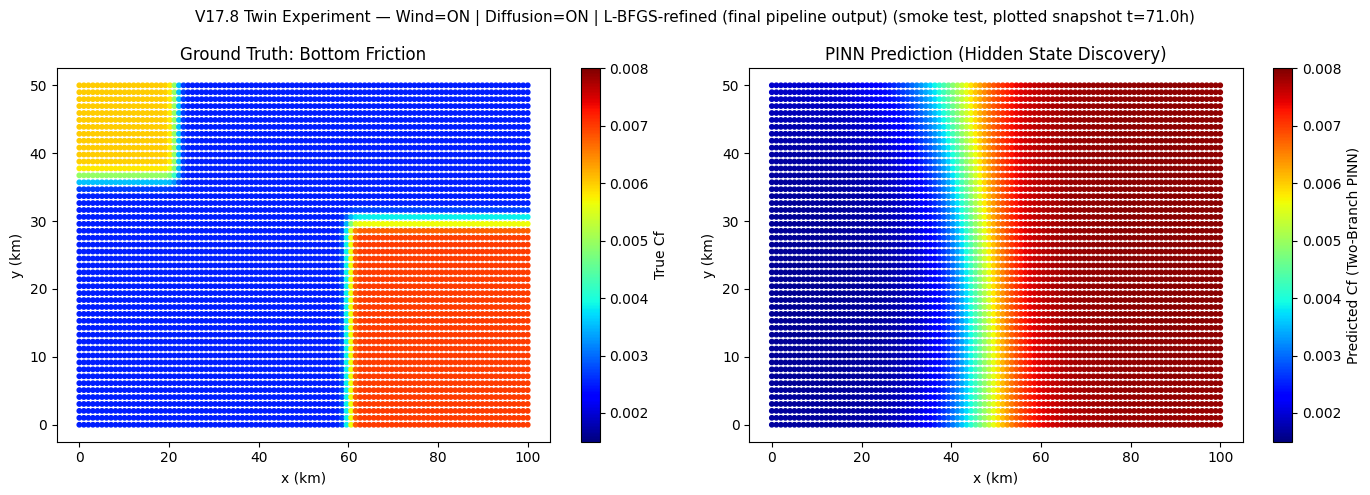


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.3478 meters (Assimilated)
🚤 Long. Velocity (u) MAE: 1.2651 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.6517 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=10.87% , v=10.31% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00280 (62.33% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.4356 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = -0.037, corr(Cf_error, wind_y-pattern) = -0.671  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 62.33%, r(Cf) = 0.4356
    After L-BFGS-B: RMSE(Cf) = 65.29%, r(Cf) = 0.4222

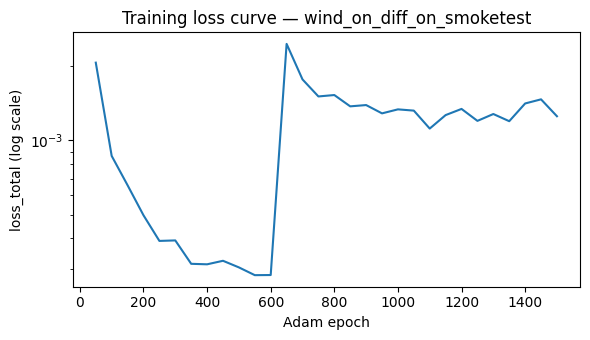

{'mae_h': np.float64(0.18654170023687044),
 'mae_u': np.float64(1.2503775165803932),
 'mae_v': np.float64(0.5670900216873097),
 'mae_u_pct_shallow': np.float64(11.045593690491913),
 'mae_v_pct_shallow': np.float64(9.317233983118266),
 'rmse_cf_pct': np.float64(65.29241220200758),
 'r_cf': np.float64(0.4222313810272385),
 'corr_wind_x': -0.037407680628659346,
 'corr_wind_y': -0.6786174380502692,
 'corr_wind_combined': np.float64(0.6786174380502692),
 'n_eval_snapshots': 60,
 'case': 'Wind=ON | Diffusion=ON',
 'mode': 'smoke',
 'training_data_sparsified': True,
 'decoupled_collocation': True,
 'total_points_data': 57598,
 'total_points_physics': 360000,
 'training_seconds': 141.00331711769104,
 'lbfgs_seconds': 14013.552275180817,
 'peak_vram_mb': None}

In [9]:
# %%
# Cell 8: Evaluate & Visualize (V17.8 — RECONCILIATION RELEASE)
#
# 💥 RECONCILIATION: this cell merges Series 1's full-trajectory evaluation protocol +
# _predict_chunked + explicit Adam-vs-L-BFGS RMSE(Cf) comparison (VB13) with Series 2's
# explicit SMOKE_TEST guard against corrupting the canonical ablation table. These two changes
# touch disjoint parts of evaluate_model() (the evaluation math vs. a guard clause before
# saving results) and do not conflict.
#
# From Series 1:
#   1. EVALUATION TIMING FIX — V17.6/Series-2 evaluated every headline metric (mae_h, mae_u,
#      mae_v, the H1a shallow-water check) at t_raw.min(), the FIRST saved snapshot, where the
#      spin-up ramp is exactly 0 — wind and tidal forcing are both zero there, so true u,v (and
#      h) are ~0 and a network predicting ~0 everywhere would score well by accident. This cell
#      instead evaluates against EVERY saved snapshot at or after spin-up ends. The
#      shallow/deep depth mask (D=h-b) is computed PER ROW at its own time.
#   2. CHUNKED PREDICTION (_predict_chunked) to bound peak memory for the larger evaluation set.
#   3. ADAM-VS-L-BFGS COMPARISON — closes the VB13 promise/code gap: loads and evaluates BOTH
#      checkpoints when config.EVALUATE_ADAM_STAGE_SEPARATELY is True (default), printing an
#      explicit before/after RMSE(Cf) comparison and flagging a Radfar-style degradation.
#   4. PROVENANCE AWARENESS — warns if the loaded .npz predates the stable-advection generator.
#
# From Series 2:
#   5. SMOKE_TEST GUARD — an explicit assert before any result is written into the canonical
#      ablation-comparison table, refusing to let a smoke-test run silently corrupt it via an
#      accidental run_id collision with a canonical full-run tag.
#
# What is UNCHANGED from V17.6/both V17.7 series: the "Colloc" ablation-table column and
# cross-scenario consistency warning, the cost/VRAM reporting, and the §8.1 forcing-aliasing
# diagnostics (wind-off vs. full-model RMSE(Cf) delta, spatial-fingerprint correlation).


def _predict_chunked(model_apply, params, t_norm_flat, x_norm_flat, y_norm_flat, chunk_size=100_000):
    """Memory-bounded forward pass over a (possibly large) flat array of normalized (t,x,y)
    points. Returns denormalized (h, u, v, Cf) as numpy arrays. (Series 1 addition.)"""
    vmap_apply = jax.vmap(model_apply, in_axes=(None, 0, 0, 0))
    n = t_norm_flat.shape[0]
    h_parts, u_parts, v_parts, cf_parts = [], [], [], []
    for lo in range(0, n, chunk_size):
        hi = min(lo + chunk_size, n)
        h_c, u_c, v_c, cf_c = vmap_apply(
            params,
            jnp.array(t_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(x_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(y_norm_flat[lo:hi], dtype=jnp.float64),
        )
        h_parts.append(np.array(h_c)); u_parts.append(np.array(u_c))
        v_parts.append(np.array(v_c)); cf_parts.append(np.array(cf_c))
    h_star = np.concatenate(h_parts); u_star = np.concatenate(u_parts)
    v_star = np.concatenate(v_parts); cf_star = np.concatenate(cf_parts)
    h_real, u_real, v_real, cf_real = utils_scaling.denormalize_outputs(h_star, u_star, v_star, cf_star)
    return np.array(h_real), np.array(u_real), np.array(v_real), np.array(cf_real)


def _pct_of_range(pred, true_at_eval, mask=None, range_source=None, range_mask=None):
    p, t = (pred[mask], true_at_eval[mask]) if mask is not None else (pred, true_at_eval)
    if p.size == 0:
        return np.nan
    if range_source is not None:
        rs = range_source[range_mask] if range_mask is not None else range_source
    else:
        rs = t
    rng = rs.max() - rs.min()
    return 100.0 * np.mean(np.abs(p - t)) / rng if rng > 0 else np.nan


def _evaluate_checkpoint(weights_path, model_apply, raw_data, label, case_label, do_plot):
    """Core evaluation for ONE saved checkpoint (Adam-only or L-BFGS-refined)."""
    try:
        with open(weights_path, 'rb') as f:
            params = pickle.load(f)
    except FileNotFoundError:
        return None

    x_raw, y_raw, t_raw = raw_data['x'], raw_data['y'], raw_data['t']
    h_true, u_true, v_true, Cf_true = raw_data['h'], raw_data['u'], raw_data['v'], raw_data['Cf_true']
    b_true_raw = raw_data['b_true']
    t_flat_all = t_raw.flatten()

    if 'spinup_duration_physical_s' in raw_data:
        spinup_s = float(raw_data['spinup_duration_physical_s'][0])
    else:
        spinup_s = config.SPINUP_DURATION_PHYSICAL
        print(f"    ℹ️ Dataset predates the stored spin-up field — falling back to "
              f"config.SPINUP_DURATION_PHYSICAL ({spinup_s/3600:.1f}h) to define the "
              f"post-spin-up evaluation window.")
    eval_mask = (t_flat_all >= spinup_s)
    if not np.any(eval_mask):
        print("    ⚠️ No saved snapshot is at/after the spin-up window — falling back to the "
              "full saved time series for evaluation (results may include near-rest states).")
        eval_mask = np.ones_like(t_flat_all, dtype=bool)
    n_eval_snapshots = len(np.unique(t_flat_all[eval_mask]))

    x_eval, y_eval, t_eval = x_raw.flatten()[eval_mask], y_raw.flatten()[eval_mask], t_flat_all[eval_mask]
    x_norm, y_norm = utils_scaling.normalize_spatial(x_eval, y_eval)
    t_norm = utils_scaling.normalize_temporal(t_eval)

    h_pred, u_pred, v_pred, Cf_pred = _predict_chunked(model_apply, params, t_norm, x_norm, y_norm)

    h_true_flat = h_true.flatten()[eval_mask]
    u_true_flat = u_true.flatten()[eval_mask]
    v_true_flat = v_true.flatten()[eval_mask]
    b_true_flat = b_true_raw.flatten()[eval_mask]
    cf_true_flat = Cf_true.flatten()[eval_mask]  # time-invariant by construction

    mae_h = np.mean(np.abs(h_pred - h_true_flat))
    mae_u = np.mean(np.abs(u_pred - u_true_flat))
    mae_v = np.mean(np.abs(v_pred - v_true_flat))

    D_true_flat = h_true_flat - b_true_flat
    shallow_mask = D_true_flat < 40.0
    n_shallow = int(shallow_mask.sum())

    mae_u_pct_shallow = _pct_of_range(u_pred, u_true_flat, shallow_mask,
                                       range_source=u_true_flat, range_mask=None)
    mae_v_pct_shallow = _pct_of_range(v_pred, v_true_flat, shallow_mask,
                                       range_source=v_true_flat, range_mask=None)

    cf_range = cf_true_flat.max() - cf_true_flat.min()
    rmse_cf = np.sqrt(np.mean((Cf_pred - cf_true_flat) ** 2))
    rmse_cf_pct = 100.0 * rmse_cf / cf_range if cf_range > 0 else np.nan
    r_cf = np.corrcoef(Cf_pred, cf_true_flat)[0, 1]

    cf_error_flat = Cf_pred - cf_true_flat
    wind_pattern_x = np.sin(np.pi * y_eval / (config.L_REF / 2.0))
    wind_pattern_y = np.cos(np.pi * x_eval / config.L_REF)
    if np.std(cf_error_flat) > 0:
        corr_wind_x = float(np.corrcoef(cf_error_flat, wind_pattern_x)[0, 1])
        corr_wind_y = float(np.corrcoef(cf_error_flat, wind_pattern_y)[0, 1])
    else:
        corr_wind_x, corr_wind_y = np.nan, np.nan
    corr_wind_combined = (np.nanmax([abs(corr_wind_x), abs(corr_wind_y)])
                           if not (np.isnan(corr_wind_x) and np.isnan(corr_wind_y)) else np.nan)

    print(f"\n--- [{label}] ---")
    print(f"    Evaluation window: t >= {spinup_s/3600:.1f}h (post-spin-up), "
          f"{n_eval_snapshots} snapshot(s), {t_eval.shape[0]} total (t,x,y) rows")
    print(f"🌊 Water Level (h) MAE: {mae_h:.4f} meters (Assimilated)")
    print(f"🚤 Long. Velocity (u) MAE: {mae_u:.4f} m/s (INFERRED - Hidden State)")
    print(f"🚤 Lat. Velocity (v) MAE: {mae_v:.4f} m/s (INFERRED - Hidden State)")
    if n_shallow > 0:
        print(f"🎯 H1a check (shallow water D<40m, n={n_shallow} pts, post-spin-up trajectory): "
              f"u={mae_u_pct_shallow:.2f}% , v={mae_v_pct_shallow:.2f}% of true velocity range "
              f"[success criterion: < 15%]")
    else:
        print("🎯 H1a check: no evaluation points with D<40m in this dataset — cannot assess.")
    print(f"🎯 Cf RMSE: {rmse_cf:.5f} ({rmse_cf_pct:.2f}% of true range) "
          f"[success criterion §8.1: < 5%]")
    print(f"🎯 Cf spatial correlation r = {r_cf:.4f} [success criterion §8.1: r > 0.95]")
    print(f"🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = {corr_wind_x:.3f}, "
          f"corr(Cf_error, wind_y-pattern) = {corr_wind_y:.3f}  "
          f"[high |corr| under Wind=OFF => spatial aliasing signature; "
          f"low |corr| under Wind=ON => aliasing resolved]")

    if do_plot:
        plot_row_mask = (t_eval == t_eval.max())  # last post-spin-up snapshot: active forcing
        plt.figure(figsize=(14, 5))
        plt.suptitle(f"V17.8 Twin Experiment — {case_label} | {label} "
                     f"({'smoke test' if config.SMOKE_TEST else 'full run'}, "
                     f"plotted snapshot t={t_eval.max()/3600:.1f}h)", fontsize=11)

        plt.subplot(1, 2, 1)
        sc1 = plt.scatter(x_eval[plot_row_mask]/1000, y_eval[plot_row_mask]/1000,
                           c=cf_true_flat[plot_row_mask], cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc1, label='True Cf')
        plt.title("Ground Truth: Bottom Friction")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.subplot(1, 2, 2)
        sc2 = plt.scatter(x_eval[plot_row_mask]/1000, y_eval[plot_row_mask]/1000,
                           c=Cf_pred[plot_row_mask], cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc2, label='Predicted Cf (Two-Branch PINN)')
        plt.title("PINN Prediction (Hidden State Discovery)")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.tight_layout()
        plt.show()

    return {"mae_h": mae_h, "mae_u": mae_u, "mae_v": mae_v,
            "mae_u_pct_shallow": mae_u_pct_shallow, "mae_v_pct_shallow": mae_v_pct_shallow,
            "rmse_cf_pct": rmse_cf_pct, "r_cf": r_cf,
            "corr_wind_x": corr_wind_x, "corr_wind_y": corr_wind_y,
            "corr_wind_combined": corr_wind_combined,
            "n_eval_snapshots": n_eval_snapshots}


def evaluate_model():
    print("\n--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery, V17.8) ---")
    tag = config.scenario_tag()
    rid = config.run_id()
    case_label = f"Wind={'ON' if config.ENABLE_WIND else 'OFF'} | Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'}"
    print(f"    Ablation case: {case_label}  (tag: {tag}, mode: {'smoke' if config.SMOKE_TEST else 'full'}, run_id: {rid})")

    # 💥 Series-2 guard, retained in V17.8: refuse to let a smoke-test run silently corrupt the
    # canonical ablation-comparison table via a run_id collision with a canonical full-run tag.
    canonical_tags_guard = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]
    assert not (config.SMOKE_TEST and rid in canonical_tags_guard), (
        f"SMOKE_TEST=True but run_id '{rid}' matches a canonical full-run tag — refusing to "
        f"store this result, as it would corrupt the ablation comparison."
    )

    model_init, model_apply = init_and_apply_model()
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'
    if not os.path.exists(lbfgs_path):
        print(f"❌ Weights not found at {lbfgs_path}. Run Cells 6 and 7 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.SMOKE_TEST settings first.")
        return

    raw_data = np.load(config.DATA_PATH)

    gen_version = str(raw_data['generator_version'][0]) if 'generator_version' in raw_data else None
    if gen_version is not None and gen_version not in _KNOWN_STABLE_ADVECTION_TAGS:
        print(f"    🔴 CRITICAL WARNING: {config.DATA_PATH} was generated by tag {gen_version!r}, "
              f"which predates the upwind-advection stability fix (Cell 3). Any RMSE(Cf)/MAE "
              f"numbers below are evaluating a model trained on an unstable, mostly-clipped "
              f"ground truth and MUST NOT be reported or cited. Regenerate via this version's "
              f"Cell 3 before trusting anything printed below.")
    elif gen_version == 'V17.7_sharper_cf_rotating_wind':
        print(f"    ℹ️ NOTE: {config.DATA_PATH} predates V17.8's config reconciliation but IS "
              f"numerically compatible (same stable advection scheme). Fine to use.")

    sparsified = bool(raw_data['satellite_sparsification_enabled'][0]) if 'satellite_sparsification_enabled' in raw_data else None
    if sparsified is not None:
        print(f"    🛰️  Training DATA pool for this run was "
              f"{'SATELLITE-SPARSIFIED (stylized proxy — see Cell 3)' if sparsified else 'DENSE (sparsification OFF)'}. "
              f"Evaluation below is always against the full dense grid regardless.")

    history_path_early = f'data/training_history_v17_{rid}.pkl'
    decoupled_collocation, total_points_data, total_points_physics = None, None, None
    if os.path.exists(history_path_early):
        with open(history_path_early, 'rb') as f:
            _hp_early = pickle.load(f)
        decoupled_collocation = _hp_early.get('decoupled_collocation')
        total_points_data = _hp_early.get('total_points_data')
        total_points_physics = _hp_early.get('total_points_physics')
        if decoupled_collocation is not None:
            print(f"    🧩 Physics-collocation design used in training: "
                  f"{'DECOUPLED, full-domain (default)' if decoupled_collocation else 'COUPLED to satellite mask (V17.4-equivalent — physics under-enforced away from the satellite footprint)'} "
                  f"| data points={total_points_data}, physics points={total_points_physics}")

    # --- Primary result: the final pipeline output (L-BFGS-refined weights) ---
    result = _evaluate_checkpoint(lbfgs_path, model_apply, raw_data,
                                   label="L-BFGS-refined (final pipeline output)",
                                   case_label=case_label, do_plot=True)

    # --- Explicit Adam-only-vs-L-BFGS comparison, per §9.4/VB13's commitment ---
    if getattr(config, 'EVALUATE_ADAM_STAGE_SEPARATELY', False):
        adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
        result_adam = _evaluate_checkpoint(adam_path, model_apply, raw_data,
                                            label="Adam-only (pre-L-BFGS)",
                                            case_label=case_label, do_plot=False)
        if result_adam is not None:
            d_rmse = result["rmse_cf_pct"] - result_adam["rmse_cf_pct"]
            print(f"\n--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---")
            print(f"    Adam-only:      RMSE(Cf) = {result_adam['rmse_cf_pct']:.2f}%, r(Cf) = {result_adam['r_cf']:.4f}")
            print(f"    After L-BFGS-B: RMSE(Cf) = {result['rmse_cf_pct']:.2f}%, r(Cf) = {result['r_cf']:.4f}")
            if d_rmse > 5.0:
                print(f"    🚨 L-BFGS-B WORSENED RMSE(Cf) by {d_rmse:.2f} percentage points — "
                      f"consistent with the Radfar (2026) pathology cited in §9.4/VB13. Per the "
                      f"proposal's own decision rule, the ADAM-ONLY checkpoint should be treated "
                      f"as the primary reported result for this scenario.")
            elif d_rmse > 0:
                print(f"    ⚠️ L-BFGS-B mildly worsened RMSE(Cf) by {d_rmse:.2f} points — within "
                      f"noise for a single run, but worth checking across ensemble members "
                      f"(Phase 3) and against the Cell 7 subset-sensitivity sweep before "
                      f"treating L-BFGS-B as unconditionally safe.")
            else:
                print(f"    ✅ L-BFGS-B improved (or did not worsen) RMSE(Cf) by "
                      f"{abs(d_rmse):.2f} percentage points for this run.")
        else:
            print(f"\n    ℹ️ Adam-only weights not found at {adam_path} — skipping the VB13 "
                  f"before/after comparison for this run.")

    if config.SMOKE_TEST:
        print("\n   ℹ️ SMOKE-TEST MODE: these numbers assess pipeline health only (short "
              "duration, reduced epochs) — they are NOT valid for §8.1 scenario comparison. "
              "Re-run with config.SMOKE_TEST=False for numbers that count.")

    history_path = f'data/training_history_v17_{rid}.pkl'
    training_seconds, peak_vram_mb, lbfgs_seconds, loss_history = None, None, None, None
    if os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            history_payload = pickle.load(f)
        training_seconds = history_payload.get('training_seconds')
        peak_vram_mb = history_payload.get('peak_vram_mb')
        lbfgs_seconds = history_payload.get('lbfgs_seconds')
        loss_history = history_payload.get('loss_history')
        decoupled_collocation = history_payload.get('decoupled_collocation', decoupled_collocation)
        total_points_data = history_payload.get('total_points_data', total_points_data)
        total_points_physics = history_payload.get('total_points_physics', total_points_physics)

        if training_seconds is not None and lbfgs_seconds is not None:
            total_seconds = training_seconds + lbfgs_seconds
            vram_str = f"{peak_vram_mb:.0f} MB" if peak_vram_mb is not None else "unavailable"
            print(f"\n⏱️  Cost: Adam={training_seconds:.1f}s, L-BFGS={lbfgs_seconds:.1f}s, "
                  f"total={total_seconds:.1f}s, peak VRAM={vram_str}")
        else:
            print("\n⏱️  Cost: partial data only in training-history file.")

        if loss_history:
            epochs_arr = [pt['epoch'] for pt in loss_history]
            loss_arr = [pt['loss_total'] for pt in loss_history]
            plt.figure(figsize=(6, 3.5))
            plt.plot(epochs_arr, loss_arr)
            plt.yscale('log')
            plt.xlabel("Adam epoch")
            plt.ylabel("loss_total (log scale)")
            plt.title(f"Training loss curve — {rid}")
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n⏱️  No training-history file found at {history_path} "
              f"(Cell 6 wasn't run under this exact run_id) — cost/loss-curve skipped.")

    result.update({"case": case_label, "mode": "smoke" if config.SMOKE_TEST else "full",
                    "training_data_sparsified": sparsified,
                    "decoupled_collocation": decoupled_collocation,
                    "total_points_data": total_points_data,
                    "total_points_physics": total_points_physics,
                    "training_seconds": training_seconds, "lbfgs_seconds": lbfgs_seconds,
                    "peak_vram_mb": peak_vram_mb})

    results_path = 'data/ablation_results_v17.pkl'
    all_results = {}
    if os.path.exists(results_path):
        with open(results_path, 'rb') as f:
            all_results = pickle.load(f)
    all_results[rid] = result
    with open(results_path, 'wb') as f:
        pickle.dump(all_results, f)

    canonical_tags = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]  # full-run only
    if any(t in all_results for t in canonical_tags):
        print("\n--- 📊 ABLATION COMPARISON (§8.1, FULL RUNS ONLY — smoke tests excluded) ---")
        header = (f"{'Scenario':<20}{'RMSE(Cf) %':>12}{'r(Cf)':>10}{'MAE h':>10}{'MAE u':>10}"
                  f"{'MAE v':>10}{'Corr(err,W)':>13}{'Pass?':>8}{'Time(s)':>10}{'VRAM(MB)':>10}{'Colloc':>10}")
        print(header)
        print("-" * len(header))
        for t in canonical_tags:
            if t in all_results:
                r = all_results[t]
                passed = "✅" if (r['rmse_cf_pct'] < 5.0 and r['r_cf'] > 0.95) else "⚠️"
                ts = r.get('training_seconds')
                ls = r.get('lbfgs_seconds')
                total_t = f"{(ts or 0)+(ls or 0):.0f}" if (ts is not None or ls is not None) else "—"
                vram = f"{r['peak_vram_mb']:.0f}" if r.get('peak_vram_mb') is not None else "—"
                cwc = r.get('corr_wind_combined')
                corr_str = f"{cwc:.3f}" if cwc is not None and not np.isnan(cwc) else "—"
                dc = r.get('decoupled_collocation')
                colloc_str = "decoup." if dc is True else ("coupled" if dc is False else "—")
                print(f"{t:<20}{r['rmse_cf_pct']:>12.2f}{r['r_cf']:>10.3f}"
                      f"{r['mae_h']:>10.4f}{r['mae_u']:>10.4f}{r['mae_v']:>10.4f}"
                      f"{corr_str:>13}{passed:>8}{total_t:>10}{vram:>10}{colloc_str:>10}")
            else:
                print(f"{t:<20}{'— not run yet —':>93}")

        colloc_flags = [all_results[t].get('decoupled_collocation') for t in canonical_tags if t in all_results]
        if len(set(colloc_flags)) > 1:
            print("\n   ⚠️ WARNING: the three scenarios above were NOT all trained under the same "
                  "collocation design (decoupled vs. coupled) — this table is comparing results "
                  "from different optimization problems.")

        if all(t in all_results for t in canonical_tags):
            delta = all_results["wind_off_diff_off"]["rmse_cf_pct"] - all_results["wind_on_diff_on"]["rmse_cf_pct"]
            if delta > 0:
                print(f"\n   🎯 Forcing-aliasing evidence (amplitude): RMSE(Cf) improved by {delta:.2f} "
                      f"percentage points from wind-off to the full V17 model.")
            elif delta < 0:
                print(f"\n   ⚠️ RMSE(Cf) got WORSE by {abs(delta):.2f} percentage points from "
                      f"wind-off to the full V17 model — investigate before final reporting.")
            else:
                print(f"\n   • RMSE(Cf) showed no change from wind-off to the full V17 model.")

            corr_off = all_results["wind_off_diff_off"].get("corr_wind_combined")
            corr_on = all_results["wind_on_diff_on"].get("corr_wind_combined")
            if corr_off is not None and corr_on is not None and not (np.isnan(corr_off) or np.isnan(corr_on)):
                verdict = "Consistent with aliasing being resolved." if corr_on < corr_off else "Does NOT show the expected reduction — investigate."
                print(f"   🌀 Forcing-aliasing evidence (spatial fingerprint): |corr(err,wind)| = "
                      f"{corr_off:.3f} (wind-off) -> {corr_on:.3f} (full model). {verdict}")

    return result

evaluate_model()
